The notebook is divided in these parts:
## 1.   *Importing Libraries*
## 2.   *Importing Dataset*
## 3.   *Preprocessing*
## 4.   *Feature Engineering*
## 5.   *Model Training*
## 6.   *Evaluation and Prediction*
## 7.   *Deployment*
---

# 📔 Project Notebook Structure
```bibtex
1. Tasks are distributed across teams and organized by notebook titles
   Each notebook documents:
    - Code implementation for task completion
    - Relevant comments and annotations

2. Agile Project Methodology:
    Weekly iterations training 1-2 models

    Project completion criteria:
        Best performing model achieves target evaluation metrics

3. The Pipeline of notebook:
   a. Doing EDA on dataset and finding information about that
   
   b. Applying preprocessing on dataset by information:
      i.   Class balancing
      ii.  Data augmentation
      iii. Normalization
      iv.  De-noising

   c. Feature extraction:
      i. Using some trained model
      ii. Extracting using Deep Learning (MFCC, MEL spectograms)

   d. Model training:
      i. Using trained model and fine tune that
      ii. Implement from scratch with torch, keras

   e. Evaluation with accuracy, precision, recall, f1-score (Confusion Matrix)
```

💡 Tips:
``` python
  1. For unfinished section use this: #TODO
  2. The structure of task like this:
      # [TASK NAME] (Assignee: @username)
      # Sprint Goal: [e.g., "Improve Wav2Vec2 accuracy by 5%"]
      # Deadline: DD/MM  
```


# 1. *Libraries*



**Installing**



In [1]:
!pip install numpy==2.0.0 -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.3/19.3 MB 48.2 MB/s eta 0:00:00


In [2]:
!pip install noisereduce openai-whisper datasets evaluate jiwer torchsummary -q -U

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 800.5/800.5 kB 12.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 49.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.3 MB/s 

**Importing**

In [3]:
# For Data Processing
import numpy as np
import pandas as pd
import os
import shutil
import random
import json
import datetime
import zipfile
import kagglehub
from sklearn.utils import shuffle
from tqdm import tqdm
from pathlib import Path
from evaluate import load
from sklearn.utils import resample
from pathlib import Path

#  For Plotting
import matplotlib.pyplot as plt
import seaborn as sns


# For Speech Processing
import torchaudio
import librosa
import scipy.signal as signal
import IPython.display as ipd
import soundfile as sf
import noisereduce as nr
import torchaudio.transforms as T

# For DL, Classifier,... Model (Sklearn, pytorch, keras, Tensorflow,...)
import tensorflow_hub as hub
import whisper
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils import spectral_norm
import tensorflow as tf
from torch.utils.data import DataLoader, TensorDataset, Dataset
from torchvision import transforms
from torch.utils.tensorboard import SummaryWriter
from torchsummary import summary
from transformers import Wav2Vec2Processor, Wav2Vec2ForCTC, TrainingArguments, Trainer, Wav2Vec2Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, TensorBoard
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# For object oriented in python
from abc import ABC, abstractmethod
from dataclasses import dataclass
from typing import Tuple, List, Optional, Union
from collections import defaultdict

# If you need other libraries to be imported write it here


# *2. Dataset - EDA*

**`DONE`**\
Importing Dataset - (Assignee: Sepehr)\
Sprint Goal: [Importing Dataset from kaggle and making a folder in colab]\
Deadline: 02/May

In [4]:
# Importing Dataset From Kaggle
path = kagglehub.dataset_download("sepehrsimkhah/speech-dataset-pazhvak")

print("Path to dataset files:", path)

100%|██████████| 3.77G/3.77G [00:59<00:00, 68.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/sepehrsimkhah/speech-dataset-pazhvak/versions/1


In [ ]:
# Validating Dataset Path
list_of_dataset = os.listdir(path)
list_of_dataset

['1201-1600',
 '2001-2400',
 'P1993818924117826_1247741184149835.xlsx',
 '2801-3200',
 '3601-4018',
 '1-400',
 '801-1200',
 '3201-3600',
 '401-800',
 '1601-2000',
 '2401-2800']

In [ ]:
word_table = os.path.join(path, 'P1993818924117826_1247741184149835.xlsx')
df = pd.read_excel(word_table)
df.sample(5)

,Folder Number,Persian Word
2375,2376,می شناسی
2731,2732,دراچین
2374,2375,می شناسم
3816,3817,ماشین
2411,2412,می‌خوانی


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4018 entries, 0 to 4017
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Folder Number  4018 non-null   int64 
 1   Persian Word   4017 non-null   object
dtypes: int64(1), object(1)
memory usage: 62.9+ KB


In [ ]:
df.isna()

,Folder Number,Persian Word
0,False,False
1,False,False
2,False,False
3,False,False
4,False,False
...,...,...
4013,False,False
4014,False,False
4015,False,False
4016,False,False


**`DONE`**\
TODO: Fixing the voice problem (assignee: Sepehr)

In [ ]:
# by doing this we found out that we have a nan value
df_false = df[df.isna().any(axis=1)]
df_false

,Folder Number,Persian Word
662,663,NaN


i listend the voices of folder 663th and i found out that the 663 is "کارفرما"

In [ ]:
row = df[df["Persian Word"] == "کارفرما"]
row

,Folder Number,Persian Word
3778,3779,کارفرما


this word has two folders, I Don't know why but:\
a folder is "کارفرما" with men voices (3779)\
the other one is "کارفرما" with women voices (663)

In [ ]:
# it's 10 folders
list_of_folders = list_of_dataset.copy()
list_of_folders.remove('P1993818924117826_1247741184149835.xlsx')
list_of_folders

['2801-3200',
 '1-400',
 '3601-4018',
 '2001-2400',
 '401-800',
 '1601-2000',
 '3201-3600',
 '1201-1600',
 '801-1200',
 '2401-2800']

این شخص کلمه "شستن" رو خیلی باحال گفته به همین خاطر رانش نکنید

In [ ]:
# finding the audio of word by number folder

def find_word_range(folder_number:int, folders:list):
  for word_range in folders:
    start_word_range, stop_word_range = word_range.split("-")
    if int(start_word_range) <= folder_number <= int(stop_word_range):
      return start_word_range, stop_word_range, word_range

random_number_folder = random.randint(0, 4018)
word = (df[df["Folder Number"] == random_number_folder])["Persian Word"].values[0]
_, _, word_range = find_word_range(random_number_folder, list_of_folders)
path_example = os.path.join(f"{path}/{word_range}/{random_number_folder}/")
list_audio_example = os.listdir(path_example)
audio_file = path_example + list_audio_example[random.randint(0, len(list_audio_example)-1)]

print(f"Word: {word}")
print("Loading:", audio_file)
assert os.path.exists(audio_file), f"File {audio_file} not found!"

y, sr = librosa.load(audio_file, sr=None)
print(sr)
ipd.Audio(y, rate=sr)



Word: 204    شستن
Name: Persian Word, dtype: object
Loading: /kaggle/input/speech-dataset-pazhvak/1-400/205/FA_16000_0013.wav
16000


In [ ]:
# Some Examples

def play_audio_samples(path:str, word_table:pd.DataFrame, folders:list, num_samples:int=2):
    for _ in range(num_samples):
        random_number_folder = random.randint(0, len(word_table) - 1)

        word_row = word_table[word_table["Folder Number"] == random_number_folder]
        if word_row.empty:
            continue

        word = word_row["Persian Word"].values[0]
        start_range, end_range, word_range = find_word_range(random_number_folder, folders)

        folder_path = os.path.join(path, word_range, str(random_number_folder))
        if not os.path.exists(folder_path):
            print(f"Folder not found: {folder_path}")
            continue

        audio_files = os.listdir(folder_path)
        if not audio_files:
            print(f"No audio files in: {folder_path}")
            continue

        audio_file = os.path.join(folder_path, random.choice(audio_files))

        print(f"\nWord: {word} (Folder: {random_number_folder})")
        print(f"Audio file: {audio_file}")

        try:
            y, sr = librosa.load(audio_file, sr=None)
            display(ipd.Audio(y, rate=sr))
        except Exception as e:
            print(f"Error loading audio: {e}")

In [ ]:
play_audio_samples(path=path,word_table=df,folders=list_of_folders,num_samples=3)


Word: شنید  (Folder: 120)
Audio file: /kaggle/input/speech-dataset-pazhvak/1-400/120/FA_16000_0008.wav



Word: سوراخ (Folder: 591)
Audio file: /kaggle/input/speech-dataset-pazhvak/401-800/591/FA_16000_0021.wav



Word: زمین شناس (Folder: 3915)
Audio file: /kaggle/input/speech-dataset-pazhvak/3601-4018/3915/FA_16000_0015.wav


**`DONE`**\
EDA On Dataset - (Assignee: Sepehr)\
Sprint Goal: [Using some functions to analyzing voices and getting some informations]\
Deadline: 02/May

In [5]:
class IAudioAnalyzer(ABC):
    @abstractmethod
    def analyze(self, signal: np.ndarray, sample_rate: int) -> dict:
        pass

    @abstractmethod
    def plot(self, signal: np.ndarray, sample_rate: int):
        pass

#-------------------------------------------------------------
#<<<<<<<<<<<<<<<<<<<Audio Analysis>>>>>>>>>>>>>>>>>>>>>>>>>>>>
#-------------------------------------------------------------

@dataclass
class AudioSample:
    signal: np.ndarray
    sample_rate: int
    metadata: dict = None

class AudioAnalyzer:
    def __init__(self, audio_sample: AudioSample):
        self.audio = audio_sample

    def raw_waveform_plot(self):
        plt.figure(figsize=(12, 4))
        librosa.display.waveshow(y=self.audio.signal, sr=self.audio.sample_rate)
        plt.title("Raw Waveform")
        plt.show()

    def fft_spectrum_plot(self):
        fft = np.fft.fft(self.audio.signal)
        freq = np.fft.fftfreq(len(self.audio.signal), 1/self.audio.sample_rate)
        plt.figure(figsize=(12, 4))
        plt.plot(freq[:len(freq)//2], np.abs(fft)[:len(freq)//2])
        plt.title("FFT Spectrum")
        plt.xlabel("Frequency (Hz)")
        plt.ylabel("Magnitude")
        plt.show()

    def stft_spectrogram_plot(self, scale: str = "log"):
        D = librosa.stft(self.audio.signal, n_fft=2048, hop_length=512)
        s_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
        plt.figure(figsize=(12, 4))
        librosa.display.specshow(s_db, sr=self.audio.sample_rate,
                                hop_length=512, x_axis='time', y_axis=scale)
        plt.colorbar(format='%+2.0f dB')
        plt.title("STFT Spectrogram")
        plt.show()

    def mel_spectrogram_plot(self, n_mels: int = 80):
        S = librosa.feature.melspectrogram(y=self.audio.signal, sr=self.audio.sample_rate, n_mels=n_mels)
        S_db = librosa.power_to_db(S, ref=np.max)
        plt.figure(figsize=(12, 4))
        librosa.display.specshow(S_db, sr=self.audio.sample_rate, x_axis='time', y_axis='mel')
        plt.colorbar(format='%+2.0f dB')
        plt.title("Mel Spectrogram")
        plt.show()
        return S_db

    def mfcc_plot(self, n_mfcc: int = 13):
        mfccs = librosa.feature.mfcc(y=self.audio.signal, sr=self.audio.sample_rate, n_mfcc=n_mfcc)
        plt.figure(figsize=(12, 4))
        librosa.display.specshow(mfccs, sr=self.audio.sample_rate, x_axis='time')
        plt.colorbar()
        plt.title("MFCC Features")
        plt.show()


In [6]:
#-------------------------------------------------------------
#<<<<<<<<<<<<<<<<<<<<Word Analysis>>>>>>>>>>>>>>>>>>>>>>>>>>>>
#-------------------------------------------------------------

class WordAnalyzer:
    def __init__(self, dataset: 'PazhvakDataset'):
        self.dataset = dataset

    def word_count(self) -> pd.DataFrame:
        word_stats = []

        for word, group in self.dataset.metadata.groupby('Persian Word'):
            voice_count = 0
            folder_count = len(group)

            for _, row in group.iterrows():
                folder_num = row['Folder Number']
                word_range = self.dataset._find_word_range(folder_num)
                folder_path = os.path.join(self.dataset.dataset_path, word_range, str(folder_num))

                if os.path.exists(folder_path):
                    voice_count += len([f for f in os.listdir(folder_path)
                                     if f.endswith(('.wav', '.mp3', '.flac'))])

            word_stats.append({
                'Persian Word': word,
                'Voice Count': voice_count,
                'Folder Count': folder_count
            })

        return pd.DataFrame(word_stats)

    def most_common_words(self, top_n: int = 10) -> pd.DataFrame:
        word_stats = self.word_count()
        return word_stats.sort_values('Voice Count', ascending=False).head(top_n)

    def least_common_words(self, top_n: int = 10) -> pd.DataFrame:
        word_stats = self.word_count()
        return word_stats.sort_values('Voice Count').head(top_n)

    def plot_voice_distribution(self):
        word_stats = self.word_count()
        voice_counts = word_stats['Voice Count'].value_counts().sort_index()

        plt.figure(figsize=(12, 6))
        voice_counts.plot(kind='bar')
        plt.title("Distribution of Voice Counts per Word")
        plt.xlabel("Number of Voices")
        plt.ylabel("Number of Words")
        plt.grid(True)
        plt.show()

In [7]:
#-------------------------------------------------------------
#<<<<<<<<<<<<<<<<<<<Dataset Statistics>>>>>>>>>>>>>>>>>>>>>>>>
#-------------------------------------------------------------

class DatasetStatistics:
    def __init__(self, dataset: 'PazhvakDataset'):
        self.dataset = dataset

    def analyze_durations(self) -> dict:
        durations = []
        total_files = 0

        for _, row in tqdm(self.dataset.metadata.iterrows(), total=len(self.dataset.metadata), desc="Analyzing durations"):
            folder_num = row['Folder Number']
            word_range = self.dataset._find_word_range(folder_num)
            folder_path = os.path.join(self.dataset.dataset_path, word_range, str(folder_num))

            if os.path.exists(folder_path):
                audio_files = [f for f in os.listdir(folder_path)
                             if f.endswith(('.wav', '.mp3', '.flac'))]
                total_files += len(audio_files)

                for file in audio_files:
                    try:
                        y, sr = librosa.load(os.path.join(folder_path, file), sr=None)
                        durations.append(len(y)/sr)
                    except:
                        continue

        if not durations:
            return {}

        avg_dur = sum(durations)/len(durations)
        max_dur = max(durations)
        min_dur = min(durations)

        above_avg = sum(1 for d in durations if d > avg_dur)
        below_avg = len(durations) - above_avg

        return {
            'avg': avg_dur,
            'max': max_dur,
            'min': min_dur,
            'above_avg': above_avg,
            'below_avg': below_avg,
            'total_files': total_files
        }

    def plot_duration_distribution(self, sample_size: int = 500):
        durations = []
        sampled_metadata = self.dataset.metadata.sample(min(sample_size, len(self.dataset.metadata)))

        for _, row in tqdm(sampled_metadata.iterrows(), total=len(sampled_metadata), desc="Sampling durations"):
            folder_num = row['Folder Number']
            word_range = self.dataset._find_word_range(folder_num)
            folder_path = os.path.join(self.dataset.dataset_path, word_range, str(folder_num))

            if os.path.exists(folder_path):
                audio_files = [f for f in os.listdir(folder_path)
                             if f.endswith(('.wav', '.mp3', '.flac'))]
                for file in audio_files[:2]:  # Max 2 files per folder
                    try:
                        y, sr = librosa.load(os.path.join(folder_path, file), sr=None)
                        durations.append(len(y)/sr)
                    except:
                        continue

        plt.figure(figsize=(12, 6))
        plt.hist(durations, bins=50, edgecolor='black')
        plt.title("Distribution of Audio Durations")
        plt.xlabel("Duration (seconds)")
        plt.ylabel("Number of Voices")
        plt.grid(True)
        plt.show()

In [8]:
# class to return dataset information

class PazhvakDataset:
    """A class to handle Persian audio dataset with metadata and folder structure."""

    def __init__(self, dataset_path: str, metadata_file: str):
        """
        Args:
            dataset_path (str): Root path of the dataset
            metadata_file (str): Path to metadata file (Excel/CSV) relative to dataset_path
        """
        self.dataset_path = dataset_path
        self.metadata_path = os.path.join(dataset_path, metadata_file)
        self.metadata_file = metadata_file

        # Load metadata
        self.metadata = self._load_metadata()
        self.word_range_folders = self._extract_word_ranges(metadata_file)

        self.audio_analyzer = AudioAnalyzer
        self.word_analyzer = WordAnalyzer(self)
        self.stats = DatasetStatistics(self)

        # Initialize splits
        self.train_df: pd.DataFrame = None
        self.val_df: pd.DataFrame = None
        self.test_df: pd.DataFrame = None

    def _load_metadata(self) -> pd.DataFrame:
        """Load metadata file (supports .csv, .xlsx)"""
        if self.metadata_path.endswith('.csv'):
            return pd.read_csv(self.metadata_path)

        elif self.metadata_path.endswith('.xlsx'):
            return pd.read_excel(self.metadata_path)

        else:
            raise ValueError("Unsupported file format. Use .csv or .xlsx")

    def _extract_word_ranges(self, metadata_file: str) -> list:
        """Extract folder ranges from dataset path"""
        list_of_folders = os.listdir(self.dataset_path)
        list_of_folders.remove(metadata_file)
        return list_of_folders

    def __len__(self) -> int:
        """Returns total number of audio folders"""
        return len(self.word_range_folders)

    def get_all_samples(self) -> pd.DataFrame:
        """Gather all audio samples from the dataset into a DataFrame"""
        all_rows = []

        print("Gathering all audio files and labels...")
        for idx, row in self.metadata.iterrows():
            try:
                folder_number = row['Folder Number']
                label = row['Persian Word'] if 'Persian Word' in row else row['Persian Word']  # Handle typo
                range_folder = self._find_word_range(int(folder_number))

                full_path = os.path.join(self.dataset_path, range_folder, str(folder_number))
                if not os.path.exists(full_path):
                    continue

                for fname in os.listdir(full_path):
                    if fname.endswith((".npy", ".wav", ".mp3", ".flac")):
                        all_rows.append({
                            'file_path': os.path.join(full_path, fname),
                            'file_name': fname,
                            'label': label,
                            'folder_number': folder_number,
                            'original_index': idx  # Keep track of original metadata index
                        })
            except Exception as e:
                print(f"Error in row {idx}: {e}")

        return pd.DataFrame(all_rows)

    def get_audio_sample(self, index: int = None, num_samples: int = 1) -> list:
        """
        Get audio sample(s) by index or random

        Args:
            index (int): Specific index to get (None for random)
            num_samples (int): Number of samples to return (default: 1)

        Returns:
            list: List of tuples (audio_data, sample_rate, word, metadata_row)
        """
        if num_samples < 1:
            raise ValueError("num_samples must be at least 1")

        samples = []

        for _ in range(num_samples):
            current_index = index if index is not None else random.randint(0, len(self.metadata)-1)

            try:
                row = self.metadata.iloc[current_index]
                folder_num = row['Folder Number']
                word_range = self._find_word_range(folder_num)

                audio_folder = os.path.join(
                    self.dataset_path,
                    word_range,
                    str(folder_num))

                if not os.path.exists(audio_folder):
                    continue

                audio_files = [f for f in os.listdir(audio_folder) if f.endswith(('.wav', '.mp3', '.flac'))]
                if not audio_files:
                    continue

                audio_file = os.path.join(audio_folder, random.choice(audio_files))
                y, sr = librosa.load(audio_file, sr=None)

                samples.append((y, sr, row['Persian Word'], row))
            except Exception as e:
                print(f"Error loading sample {current_index}: {str(e)}")
                continue

        return samples

    def _find_word_range(self, folder_number: int) -> str:
        """Find which range folder the number belongs to"""
        for word_range in self.word_range_folders:
            start, end = map(int, word_range.split('-'))
            if start <= folder_number <= end:
                return word_range
        raise ValueError(f"Folder number {folder_number} out of range")

    def split_dataset(self, test_size: float = 0.2, val_size: float = 0.1,
                     random_state: int = 42) -> None:
        """
        Split dataset into train/val/test sets while maintaining class balance

        Args:
            test_ratio (float): Proportion for test set
            val_ratio (float): Proportion for validation set
            random_state (int): Random seed for reproducibility
        """
        all_df = self.get_all_samples()

        print(f"Splitting dataset (total samples: {len(all_df)})...")
        # First split: Train+Val vs Test
        train_val_df, test_df = train_test_split(
            all_df,
            test_size=test_size,
            stratify=all_df['label'],
            random_state=random_state
        )

        # Calculate adjusted validation size based on remaining train+val portion
        val_adjusted = val_size / (1.0 - test_size)

        # Second split: Train vs Val
        train_df, val_df = train_test_split(
            train_val_df,
            test_size=val_adjusted,
            stratify=train_val_df['label'],
            random_state=random_state
        )

        self.train_df = train_df.reset_index(drop=True)
        self.val_df = val_df.reset_index(drop=True)
        self.test_df = test_df.reset_index(drop=True)

        print(f"Train: {len(self.train_df)}, Val: {len(self.val_df)}, Test: {len(self.test_df)}")

    def export_splits(self, output_path: str) -> None:
        """
        Export train/val/test splits to disk with proper folder structure

        Args:
            output_path (str): Path to save the splits
        """
        if not all([self.train_df is not None, self.val_df is not None, self.test_df is not None]):
            raise ValueError("Splits not initialized. Call split_dataset() first")

        def save_split(df: pd.DataFrame, split: str):
            split_path = os.path.join(output_path, split, "voices")
            os.makedirs(split_path, exist_ok=True)
            entries = []

            for _, row in df.iterrows():
                new_name = f"{row['label'].replace(' ', '_')}_{row['folder_number']}_{row['file_name']}"
                dst_path = os.path.join(split_path, new_name)

                shutil.copyfile(row['file_path'], dst_path)

                entries.append({
                    "file_name": new_name,
                    "label": row['label'],
                    "folder_number": row['folder_number']
                })

            pd.DataFrame(entries).to_excel(
                os.path.join(output_path, split, "labels.xlsx"),
                index=False
            )
            print(f"[{split}] -> {len(entries)} samples written to {split}/voices and labels.xlsx")

        save_split(self.train_df, "train")
        save_split(self.val_df, "val")
        save_split(self.test_df, "test")

    def play_random_sample(self, split: str = None, num_samples: int = 1) -> None:
        """
        Play random audio samples from specified split

        Args:
            split (str): One of 'train', 'val', 'test', or None for entire dataset
            num_samples (int): Number of samples to play (default: 1)
        """
        if split not in [None, 'train', 'val', 'test']:
            raise ValueError("split must be one of: None, 'train', 'val', 'test'")

        if num_samples < 1:
            raise ValueError("num_samples must be at least 1")

        if split and not getattr(self, f"{split}_indices"):
            raise ValueError(f"{split} split not initialized. Call split_dataset() first")

        for i in range(num_samples):
            index = None
            if split == 'train':
                index = random.choice(self.train_indices)
            elif split == 'val':
                index = random.choice(self.val_indices)
            elif split == 'test':
                index = random.choice(self.test_indices)
            else:
                index = random.randint(0, len(self.metadata)-1)

            try:
                y, sr, word, metadata = self.get_audio_sample(index)[0]  # Get first (and only) sample
                print(f"\nSample #{i+1}/{num_samples}")
                print(f"Word: {word}")
                print(f"Folder: {metadata['Folder Number']}")
                print(f"Audio length: {len(y)/sr:.2f} seconds")
                display(ipd.Audio(y, rate=sr))
            except Exception as e:
                print(f"Error playing sample: {str(e)}")
                continue

In [9]:
dataset = PazhvakDataset(dataset_path=path,metadata_file='P1993818924117826_1247741184149835.xlsx')

In [ ]:
# Split dataset
dataset.split_dataset(test_size=0.2, val_size=0.1)

In [ ]:
# for exporting test
dataset.export_splits("/content/Dataset")

[train] -> 63290 samples written to train/voices and labels.xlsx
[val] -> 8100 samples written to val/voices and labels.xlsx
[test] -> 17102 samples written to test/voices and labels.xlsx


In [11]:
# testing
single_sample = dataset.get_audio_sample(index=42)
four_samples = dataset.get_audio_sample(num_samples=4)
dataset.play_random_sample()
single_sample


Sample #1/1
Word: آرایشگاه
Folder: 3285
Audio length: 2.07 seconds


[(array([0., 0., 0., ..., 0., 0., 0.], dtype=float32),
  16000,
  'پشت',
  Folder Number     43
  Persian Word     پشت
  Name: 42, dtype: object)]

In [12]:
four_samples

[(array([0., 0., 0., ..., 0., 0., 0.], dtype=float32),
  16000,
  'غلط\u200cیاب',
  Folder Number       2976
  Persian Word     غلط‌یاب
  Name: 2975, dtype: object),
 (array([0., 0., 0., ..., 0., 0., 0.], dtype=float32),
  16000,
  'گلادیتاتور',
  Folder Number          3065
  Persian Word     گلادیتاتور
  Name: 3064, dtype: object),
 (array([0., 0., 0., ..., 0., 0., 0.], dtype=float32),
  16000,
  'بخوانم',
  Folder Number      2405
  Persian Word     بخوانم
  Name: 2404, dtype: object),
 (array([0., 0., 0., ..., 0., 0., 0.], dtype=float32),
  16000,
  'فرزانه',
  Folder Number       997
  Persian Word     فرزانه
  Name: 996, dtype: object)]

In [10]:
dataset.play_random_sample(num_samples=3)


Sample #1/3
Word: می‌خوردیم
Folder: 2425
Audio length: 2.76 seconds



Sample #2/3
Word: شرمنده
Folder: 3443
Audio length: 2.89 seconds



Sample #3/3
Word: خشم
Folder: 353
Audio length: 3.50 seconds


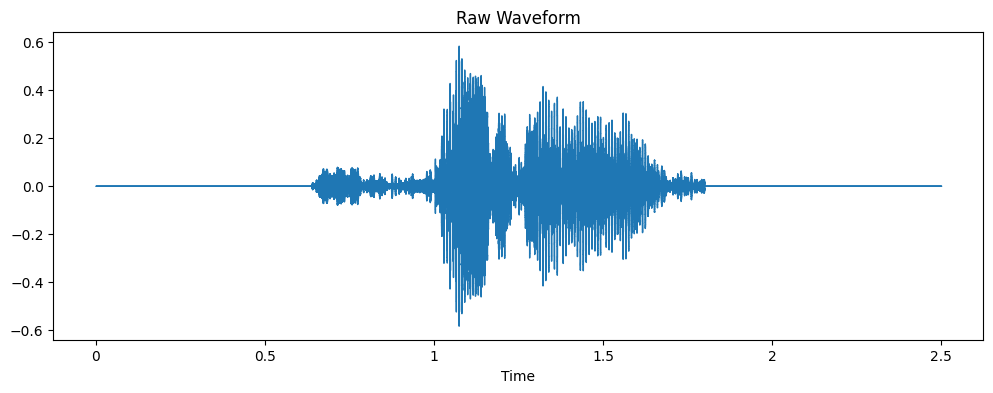

In [ ]:
# Audio Analysis Test

# Load a sample
y, sr, word, metadata = dataset.get_audio_sample()[0]
audio_sample = AudioSample(y, sr, metadata)

# Audio analysis
audio_analyzer = AudioAnalyzer(audio_sample)
audio_analyzer.raw_waveform_plot()



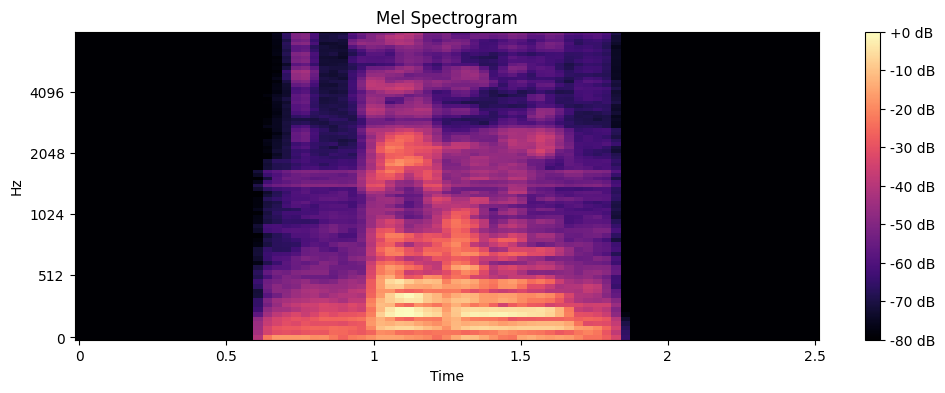

In [ ]:
audio_analyzer.mel_spectrogram_plot()
plt.show()

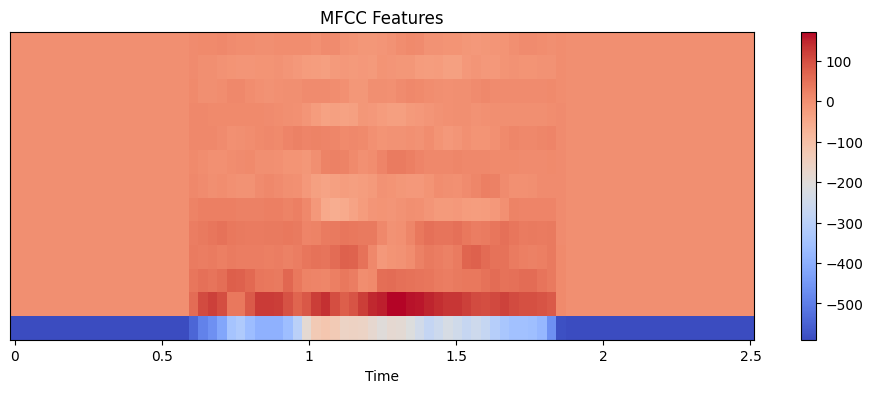

In [ ]:
audio_analyzer.mfcc_plot()

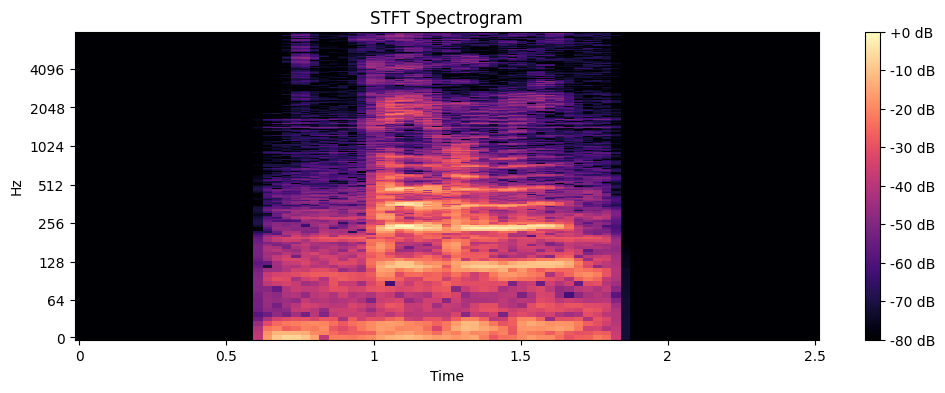

In [ ]:
audio_analyzer.stft_spectrogram_plot()

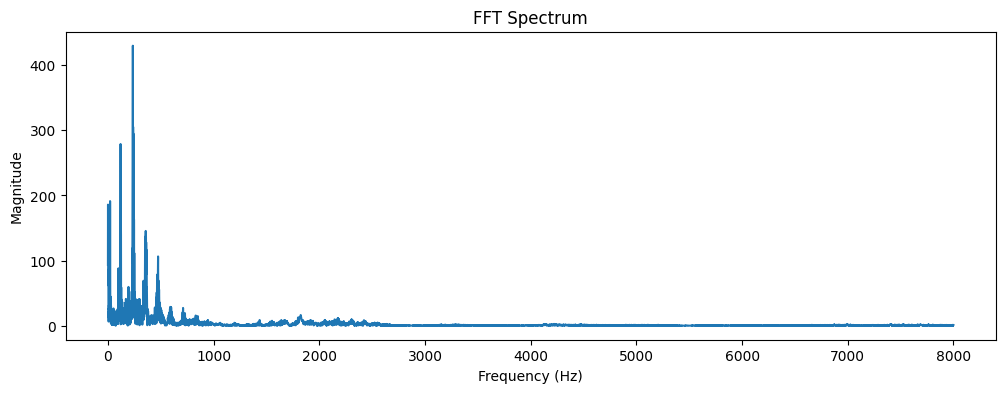

In [ ]:
audio_analyzer.fft_spectrum_plot()

In [ ]:
ipd.Audio(y, rate=sr)

In [ ]:
# Word analysis Test
word_stats = dataset.word_analyzer.word_count()
word_stats

,Persian Word,Voice Count,Folder Count
0,می گوید,14,1
1,آب,50,2
2,آب دوغ,21,1
3,آب شش,38,2
4,آب مروارید,18,1
...,...,...,...
3637,یرسند,18,1
3638,یلدا,20,1
3639,یوزپلنگ,20,1
3640,یکسان,30,1


In [ ]:
top_words = dataset.word_analyzer.most_common_words(10)
top_words

,Persian Word,Voice Count,Folder Count
1300,رسید,82,4
1550,سلام,80,3
1120,دسر,76,3
1595,سگ,70,3
1899,عجله,70,3
3082,هیچ,70,3
3053,هدف,70,3
2072,قاب,68,3
2112,قلب,68,3
5,آب نما,68,3


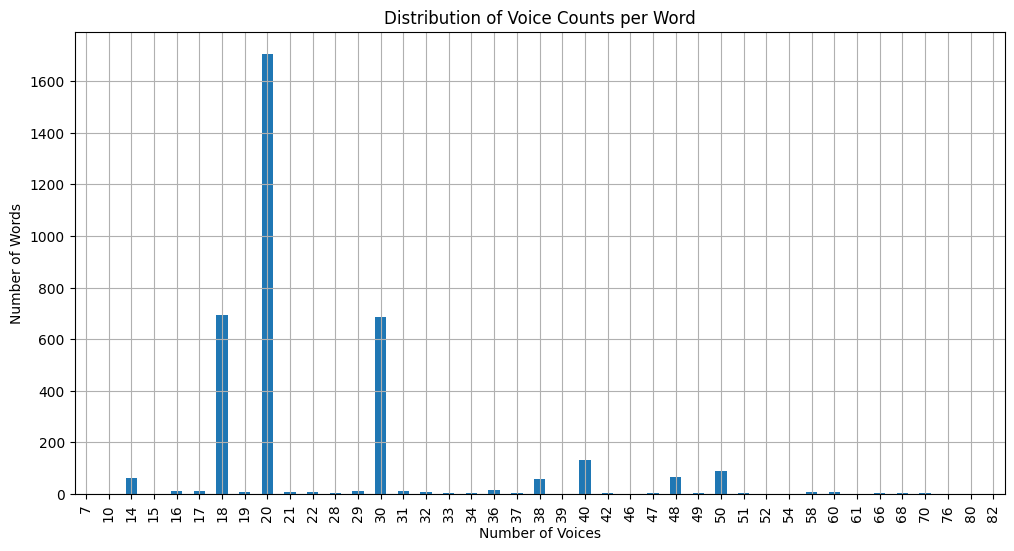

In [ ]:
dataset.word_analyzer.plot_voice_distribution()

In [ ]:
# Dataset statistics Test
duration_stats = dataset.stats.analyze_durations()
duration_stats

Analyzing durations: 100%|██████████| 4018/4018 [02:03<00:00, 32.49it/s]


{'avg': 3.1220696091084514,
 'max': 8.9836875,
 'min': 1.3166875,
 'above_avg': 38685,
 'below_avg': 49837,
 'total_files': 88522}

Sampling durations: 100%|██████████| 500/500 [00:01<00:00, 308.94it/s]


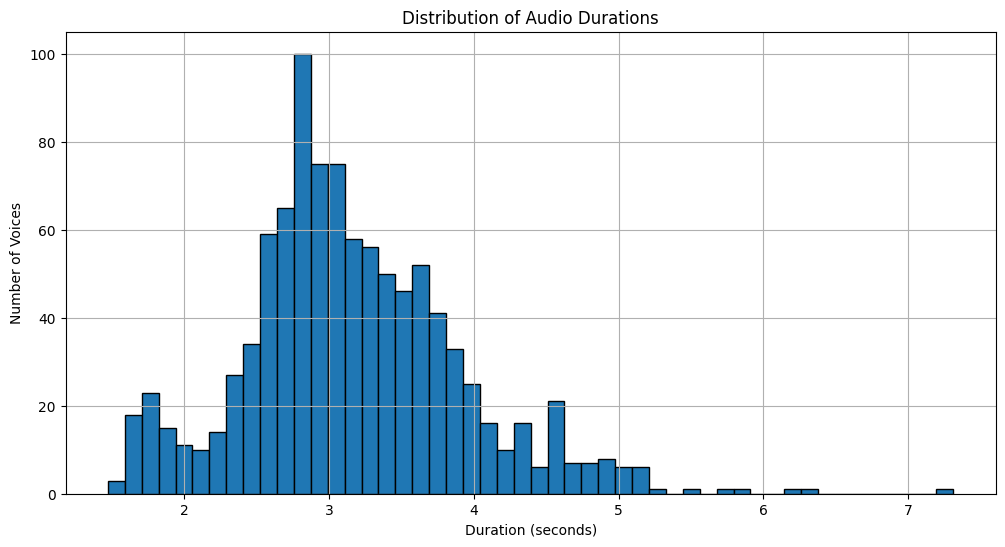

In [ ]:
dataset.stats.plot_duration_distribution()

Exploratory Data Analysis

📝 **RESULT:**



> Dataset Information: It's not good, the distribution and mis-place of voices in a folder is too much (the word is "سیب" but the voice is "پرتقال"). some of voices are not good. Dataset has good denoising and it really don't need any preprocessing but we can just use **Trim Silence, padding or trimmming, loudness normalization, normalization** preprocessing, also don't need any


```
Dataset Problem:
  feature extraction just mfcc or mel-spectrograms.
  The duration distribution is acceptable and don't need anything.
  The voice count of some words are not good and should be fixed.
  Some voices has more than avg duration which is 3.122s(like 8s).
  Some folders or voices are tagged wrongly and should be fixed.
  Lack of having not much dataset for each word and using data augmentation techniques (Maybe creating artificial voices🙂 - need to be researched).

Requirements:
  Researching about what techniques are good for preprocessing and feature extraction.
  What techniques should we do for solving our problems.
```





# *3. Preprocessing*

In [10]:
# Writing prerprocessing function for dataset
class DatasetBalancer:
    def __init__(self, dataset: 'PazhvakDataset'):
        self.dataset = dataset
        self.metadata = self._clean_metadata(dataset.metadata)

    def _clean_metadata(self, metadata: pd.DataFrame) -> pd.DataFrame:
        return metadata.dropna(subset=['Folder Number', 'Persian Word'])

    def _collect_all_word_samples(self) -> dict:
        """Collect all audio files per Persian word from all folders."""
        word_samples = defaultdict(list)

        for _, row in self.metadata.iterrows():
            folder_num = int(row['Folder Number'])
            word = row['Persian Word']
            folder_range = self.dataset._find_word_range(folder_num)
            folder_path = os.path.join(self.dataset.dataset_path, folder_range, str(folder_num))
            if os.path.exists(folder_path):
                for f in os.listdir(folder_path):
                    if f.endswith(('.wav', '.mp3', '.flac')):
                        word_samples[word].append((folder_path, f))
        return word_samples

    def _augment_audio(self, y: np.ndarray, sr: int) -> np.ndarray:
        """Apply one of several audio augmentation techniques for up sampling."""
        choice = random.choice(['noise', 'pitch', 'stretch'])
        if choice == 'noise':
            noise = np.random.normal(0, 0.005, y.shape)
            return y + noise
        elif choice == 'pitch':
            return librosa.effects.pitch_shift(y, sr, n_steps=random.choice([-2, -1, 1, 2]))
        elif choice == 'stretch':
            rate = random.uniform(0.8, 1.2)
            y_stretched = librosa.effects.time_stretch(y, rate)
            return y_stretched[:len(y)]  # Trim/pad to original length
        return y

    def balance_dataset(self, output_dataset_path: str) -> pd.DataFrame:
        os.makedirs(output_dataset_path, exist_ok=True)
        word_samples = self._collect_all_word_samples()

        avg_count = int(np.mean([len(v) for v in word_samples.values()]))
        print("The average voice count is: ",avg_count)
        new_metadata = []

        folder_counter = 1

        for word, samples in tqdm(word_samples.items(), desc="Balancing dataset"):
            total_needed = avg_count

            if len(samples) >= total_needed:
                selected = random.sample(samples, total_needed)
            else:
                selected = samples.copy()
                while len(selected) < total_needed:
                    src_folder, src_file = random.choice(samples)
                    src_path = os.path.join(src_folder, src_file)
                    try:
                        y, sr = librosa.load(src_path, sr=None)
                        y_aug = self._augment_audio(y, sr)
                        aug_id = f"{folder_counter}_{len(selected) + 1}"
                        tmp_filename = f"tmp_aug_{aug_id}.wav"
                        tmp_path = os.path.join(output_dataset_path, tmp_filename)
                        sf.write(tmp_path, y_aug, sr)
                        selected.append((output_dataset_path, tmp_filename))

                    except:
                        continue

            # Assign new folder and copy files with new naming
            folder_range = self._find_new_folder_range(folder_counter)
            folder_path = os.path.join(output_dataset_path, folder_range, str(folder_counter))
            os.makedirs(folder_path, exist_ok=True)

            for idx, (src_folder, filename) in enumerate(selected):
                new_filename = f"FA_16000_{idx + 1:04d}.wav"
                dst_path = os.path.join(folder_path, new_filename)

                if filename.startswith("tmp_aug_"):  # handle augmented audio
                    shutil.move(os.path.join(src_folder, filename), dst_path)
                else:
                    src_path = os.path.join(src_folder, filename)
                    shutil.copy2(src_path, dst_path)

            new_metadata.append((folder_counter, word))
            folder_counter += 1

        # Save new label.xlsx
        label_df = pd.DataFrame(new_metadata, columns=["Folder Number", "Persian Word"])
        label_path = os.path.join(output_dataset_path, "P1993818924117826_1247741184149835.xlsx")
        label_df.to_excel(label_path, index=False)

        return label_df

    def _find_new_folder_range(self, folder_num: int) -> str:
        """Helper to generate folder range path like '1-400', '401-800', etc."""
        range_size = 400
        start = ((folder_num - 1) // range_size) * range_size + 1
        end = start + range_size - 1
        return f"{start}-{end}"


In [11]:
# Running dataset preprocessing
balanced_dataset_path = "/content/balanced_pazhvak"
balancer = DatasetBalancer(dataset)
balanced_metadata = balancer.balance_dataset(output_dataset_path=balanced_dataset_path)


The average voice count is:  24


Balancing dataset: 100%|██████████| 3642/3642 [04:45<00:00, 12.75it/s]


In [12]:
# changing dataset path of pazhvakdataset class
dataset = PazhvakDataset(dataset_path=balanced_dataset_path, metadata_file="P1993818924117826_1247741184149835.xlsx")

In [13]:
print(len(dataset.metadata))
# from 4018 to 3642

3642


In [14]:
dataset.metadata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3642 entries, 0 to 3641
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Folder Number  3642 non-null   int64 
 1   Persian Word   3642 non-null   object
dtypes: int64(1), object(1)
memory usage: 57.0+ KB


In [19]:
# Word analysis Test
word_stats = dataset.word_analyzer.word_count()
word_stats

,Persian Word,Voice Count,Folder Count
0,می گوید,24,1
1,آب,24,1
2,آب دوغ,24,1
3,آب شش,24,1
4,آب مروارید,24,1
...,...,...,...
3637,یرسند,24,1
3638,یلدا,24,1
3639,یوزپلنگ,24,1
3640,یکسان,24,1


In [20]:
word_zero_sample = word_stats[word_stats['Voice Count'] > 24]
word_zero_sample

,Persian Word,Voice Count,Folder Count


In [21]:
word_zero_sample = word_stats[word_stats['Voice Count'] < 24]
word_zero_sample

,Persian Word,Voice Count,Folder Count


In [22]:
top_words = dataset.word_analyzer.most_common_words(10)
top_words

,Persian Word,Voice Count,Folder Count
3641,یکشنبه,24,1
0,می گوید,24,1
1,آب,24,1
2,آب دوغ,24,1
3,آب شش,24,1
4,آب مروارید,24,1
5,آب نما,24,1
6,آب و هوا,24,1
7,آب پز,24,1
8,آباد,24,1


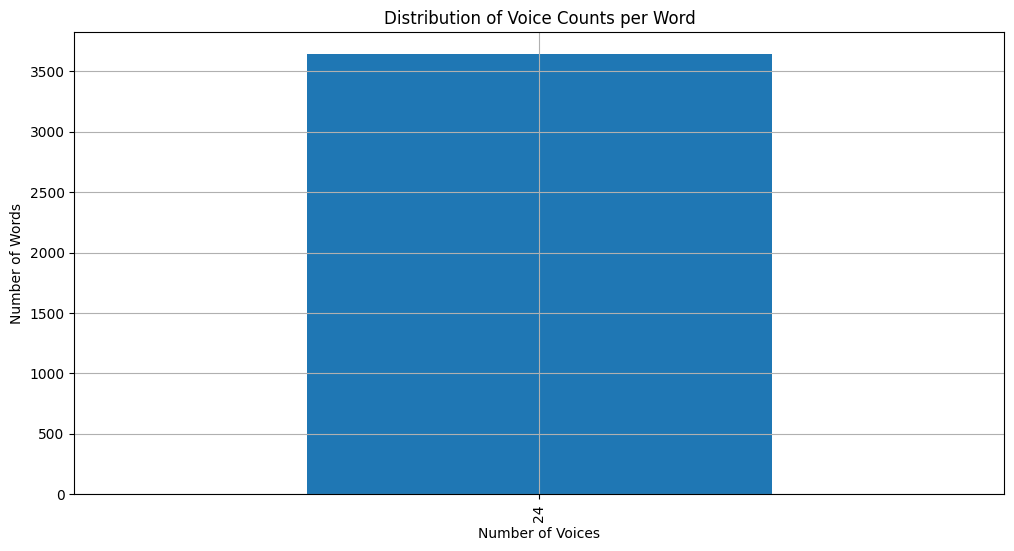

In [23]:
dataset.word_analyzer.plot_voice_distribution()

In [24]:
duration_stats = dataset.stats.analyze_durations()
duration_stats

Analyzing durations: 100%|██████████| 3642/3642 [02:32<00:00, 23.84it/s]


{'avg': 3.1407890002916967,
 'max': 8.1656875,
 'min': 1.3166875,
 'above_avg': 38268,
 'below_avg': 49140,
 'total_files': 87408}

Sampling durations: 100%|██████████| 500/500 [00:02<00:00, 191.23it/s]


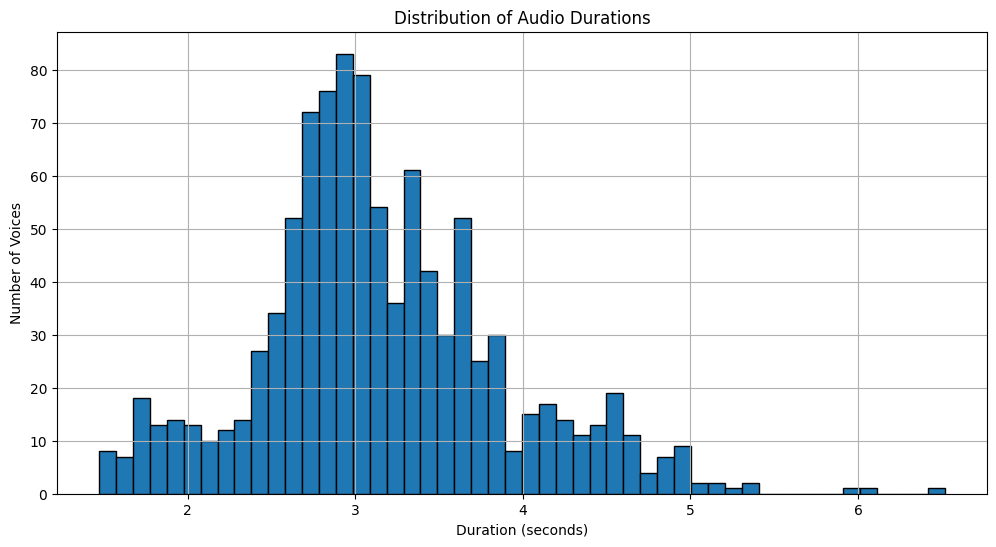

In [25]:
dataset.stats.plot_duration_distribution()

**`DONE`**\
Writing Preprocessing Functions - (Assignee: Mohammad)\
Sprint Goal: [Writing important functions for speech preprocessing]\
Deadline: 02/May

In [15]:
# Writing preprocessing function for audio


# === Parameters ===
TARGET_SAMPLE_RATE = 16000
# TARGET_DURATION = duration_stats["avg"]
# TARGET_LENGTH = int(TARGET_SAMPLE_RATE * TARGET_DURATION)
TARGET_DB = -20
TRIM_TOP_DB = 30

# === Helper Functions ===

def trim_silence(y, top_db=TRIM_TOP_DB):
    yt, _ = librosa.effects.trim(y, top_db=top_db)
    return yt

def peak_normalize(y):
    peak = np.max(np.abs(y))
    return y / peak if peak > 0 else y

def loudness_normalize(y, target_db=TARGET_DB):
    rms = np.sqrt(np.mean(y ** 2))
    target_rms = 10 ** (target_db / 20)
    return y * (target_rms / (rms + 1e-6))

def load_resample_audio(filepath:str, sample_rate:int=TARGET_SAMPLE_RATE):
    y, sr = librosa.load(filepath, sr=sample_rate, mono=True)
    return y, sr

# def padding_or_trimming(signal:list, target_length:int=TARGET_LENGTH):
#     if len(signal) > target_length:
#         return signal[:target_length]

#     elif len(signal) < target_length:
#         padding_amount = target_length - len(signal)
#         return np.pad(signal, (0, padding_amount), mode='constant')

#     else:
#         return signal.copy()


def preprocess_audio_file(input_path: str, sr:int = 16000, save_wav: bool = False, save_path: Optional[str] = None) -> Optional[np.ndarray]:
    try:
        if isinstance(input_path, str):
            if not os.path.exists(input_path):
                raise FileNotFoundError(f"File {input_path} does not exist")
            y, sr = librosa.load(input_path, sr=sr, mono=True)
        else:
            y = input_path
            sr = sr

        if y is None or len(y) == 0:
            raise ValueError("Empty audio data")

        y = nr.reduce_noise(y=y, sr=sr)
        y = trim_silence(y)
        y = peak_normalize(y)
        y = loudness_normalize(y)
        # y = padding_or_trimming(y)

        if np.any(np.isnan(y)):
            raise ValueError("NaN values detected after preprocessing")
        if np.all(y == 0):
            raise ValueError("Silent audio after preprocessing")

        if save_wav and save_path:
            sf.write(save_path, y, sr)
        return y

    except Exception as e:
        print(f"Failed to process {input_path}: {e}")

In [ ]:
# Testing preprocessing
y, sr, word, metadata = dataset.get_audio_sample()[0]
ipd.Audio(y, rate=sr)

In [ ]:
signal = preprocess_audio_file(y)
ipd.Audio(signal, rate=sr)

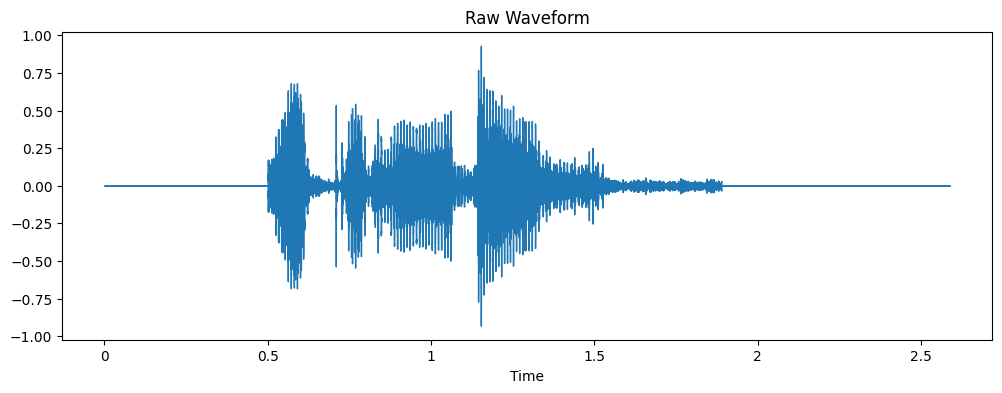

In [ ]:
audio_sample = AudioSample(y, sr, metadata)

audio_analyzer = AudioAnalyzer(audio_sample)
audio_analyzer.raw_waveform_plot()

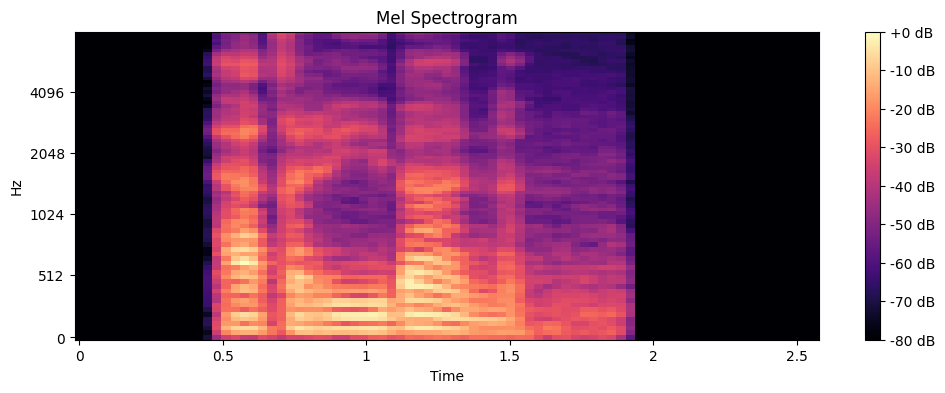

In [ ]:
audio_analyzer.mel_spectrogram_plot()
plt.show()

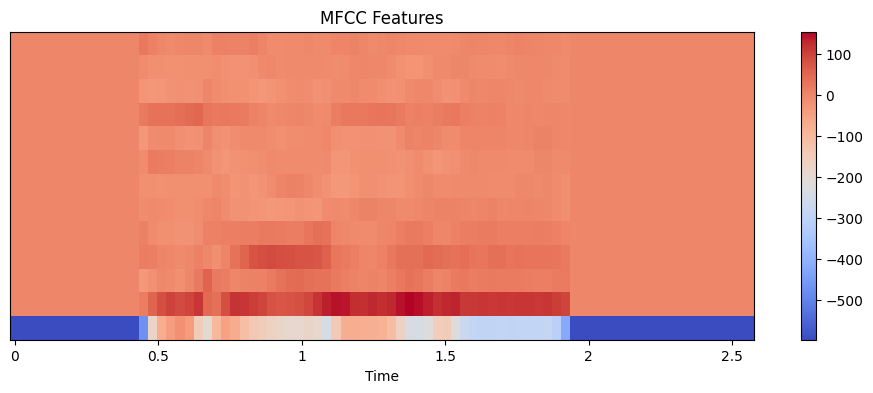

In [ ]:
audio_analyzer.mfcc_plot()

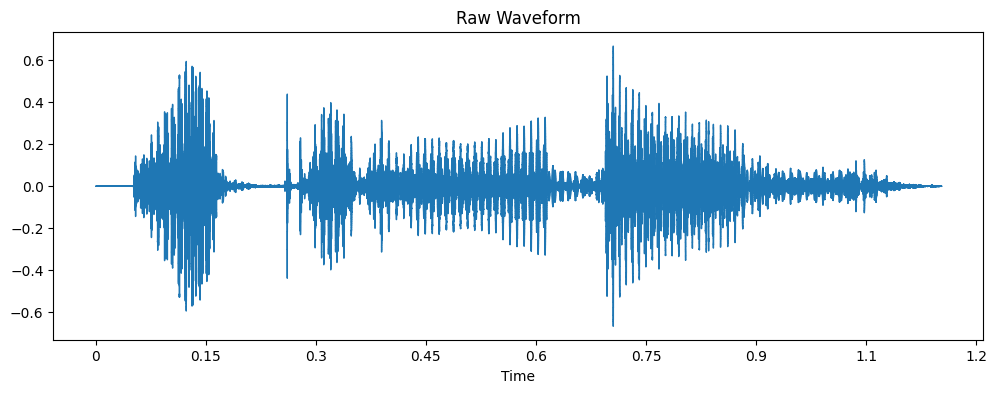

In [ ]:
# after preprocessing
audio_sample = AudioSample(signal, sr, metadata)

audio_analyzer = AudioAnalyzer(audio_sample)
audio_analyzer.raw_waveform_plot()

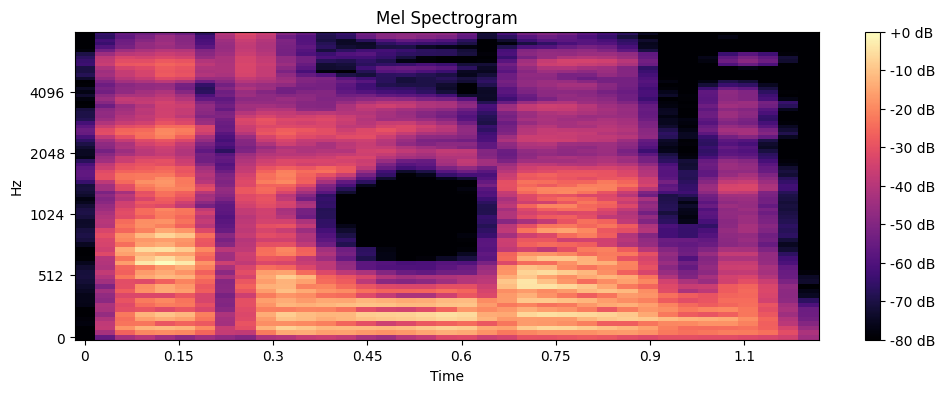

In [ ]:
audio_analyzer.mel_spectrogram_plot()
plt.show()

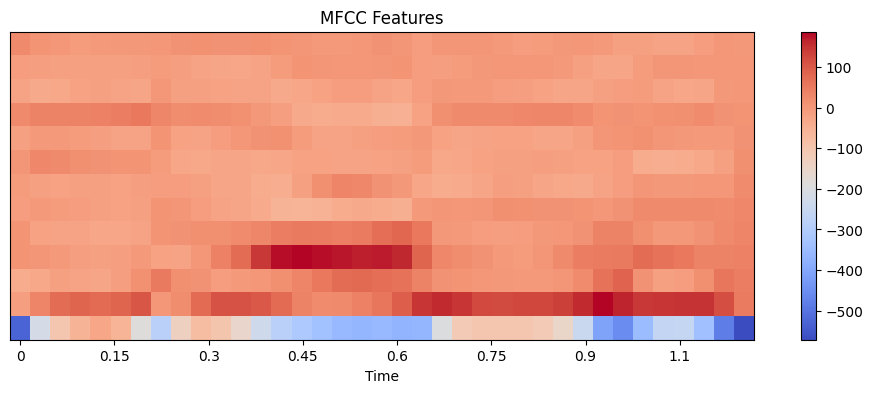

In [ ]:
audio_analyzer.mfcc_plot()

# *4. Feature Extraction*

**`DONE`**\
Writing Feature Extraction Functions - (Assignee: Shakiba)\
Sprint Goal: [Writing function for extracting features from voices for different model training]\
Deadline: 02/May

***Feature Extraction With MFCC,MEL,...***

In [16]:
# Writing Feature Extraction (without using models)

# ##############################################################
# ___________________________Features___________________________
# ##############################################################
class FeatureExtractor(ABC):
    def extract(self, audio_input: Union[str, np.ndarray], sr: int = 16000) -> np.ndarray:
        if isinstance(audio_input, str):
            y, _ = librosa.load(audio_input, sr=sr)
        elif isinstance(audio_input, np.ndarray):
            y = audio_input
        else:
            raise ValueError("Unsupported audio input type. Must be a file path or numpy array.")
        return self._extract_from_array(y, sr)

    @abstractmethod
    def _extract_from_array(self, y: np.ndarray, sr: int) -> np.ndarray:
        pass


class MFCCFeatureExtractor(FeatureExtractor):
    def __init__(self, sr: int = 16000, n_mfcc: int = 40):
        self.sr = sr
        self.n_mfcc = n_mfcc

    def _extract_from_array(self, y: np.ndarray, sr: int) -> np.ndarray:
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=self.n_mfcc)
        return mfcc.T


class MelSpectrogramExtractor(FeatureExtractor):
    def __init__(self, sr: int = 16000, n_mels: int = 128):
        self.sr = sr
        self.n_mels = n_mels

    def _extract_from_array(self, y: np.ndarray, sr: int) -> np.ndarray:
        mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=self.n_mels)
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
        return mel_spec_db


class SpectralContrastExtractor(FeatureExtractor):
    def __init__(self, sr: int = 16000, n_fft: int = 2048, hop_length: int = 512):
        self.sr = sr
        self.n_fft = n_fft
        self.hop_length = hop_length

    def _extract_from_array(self, y: np.ndarray, sr: int) -> np.ndarray:
        contrast = librosa.feature.spectral_contrast(
            y=y, sr=sr, n_fft=self.n_fft, hop_length=self.hop_length
        )
        return contrast.T


class ZeroCrossingRateExtractor(FeatureExtractor):
    def __init__(self, sr: int = 16000, frame_length: int = 2048, hop_length: int = 512):
        self.sr = sr
        self.frame_length = frame_length
        self.hop_length = hop_length

    def _extract_from_array(self, y: np.ndarray, sr: int) -> np.ndarray:
        zcr = librosa.feature.zero_crossing_rate(
            y, frame_length=self.frame_length, hop_length=self.hop_length
        )
        return zcr.T

# ##############################################################
# _________________________Handling_____________________________
# ##############################################################

class FeatureSaver:
    def __init__(self, base_output_dir: str):
        self.base_output_dir = base_output_dir

    def save(self, features: np.ndarray, rel_path: str):
        full_path = os.path.join(self.base_output_dir, rel_path)
        os.makedirs(os.path.dirname(full_path), exist_ok=True)
        np.save(full_path, features)


class HandFeatureExtraction:
    def __init__(self, dataset: 'PazhvakDataset', extractor: FeatureExtractor, feature_name: str):
        self.dataset = dataset
        self.extractor = extractor
        self.feature_name = feature_name
        self.output_dir = os.path.join(dataset.dataset_path, "features", self.feature_name)
        self.saver = FeatureSaver(self.output_dir)

    def feature_extraction(self):
        # First count total files for progress bar
        total_files = 0
        for range_folder in os.listdir(self.dataset.dataset_path):
            range_path = os.path.join(self.dataset.dataset_path, range_folder)
            if not os.path.isdir(range_path):
                continue
            for speaker_id in os.listdir(range_path):
                speaker_path = os.path.join(range_path, speaker_id)
                if not os.path.isdir(speaker_path):
                    continue
                for audio_file in os.listdir(speaker_path):
                    if audio_file.lower().endswith(('.wav', '.mp3', '.flac')):
                        total_files += 1

        # Main processing with tqdm
        with tqdm(total=total_files, desc=f"Extracting {self.feature_name}", unit="file") as pbar:
            for range_folder in os.listdir(self.dataset.dataset_path):
                range_path = os.path.join(self.dataset.dataset_path, range_folder)
                if not os.path.isdir(range_path):
                    pbar.write(f"Skipping non-folder: {range_folder}")
                    continue

                for speaker_id in os.listdir(range_path):
                    speaker_path = os.path.join(range_path, speaker_id)
                    if not os.path.isdir(speaker_path):
                        pbar.write(f"Skipping non-folder: {speaker_id}")
                        continue

                    for audio_file in os.listdir(speaker_path):
                        if not audio_file.lower().endswith(('.wav', '.mp3', '.flac')):
                            continue

                        audio_path = os.path.join(speaker_path, audio_file)
                        try:
                            features = self.extractor.extract(audio_path)
                            feature_sub_dir = os.path.join(self.output_dir, range_folder, speaker_id)
                            os.makedirs(feature_sub_dir, exist_ok=True)
                            filename = os.path.splitext(audio_file)[0] + ".npy"
                            self.saver.save(features, os.path.join(range_folder, speaker_id, filename))
                            pbar.update(1)
                        except Exception as e:
                            pbar.write(f"[✘] Failed to extract {audio_file}: {e}")
                            pbar.update(1)
        shutil.copy("/content/balanced_pazhvak/P1993818924117826_1247741184149835.xlsx", os.path.join(self.output_dir, "P1993818924117826_1247741184149835.xlsx"))

In [30]:
# MFCC
extractor = MFCCFeatureExtractor()
feature_pipeline = HandFeatureExtraction(dataset, extractor, feature_name="mfcc")
feature_pipeline.feature_extraction()

# Mel Spectrogram
# mel_extractor = MelSpectrogramExtractor()
# mel_pipeline = HandFeatureExtraction(dataset, mel_extractor, feature_name="mel")
# mel_pipeline.feature_extraction()


Extracting mfcc: 100%|██████████| 87408/87408 [22:12<00:00, 65.60file/s]

Skipping non-folder: P1993818924117826_1247741184149835.xlsx


***Feature Extraction With Trained Model (Persian ASR Model or Wav2Vec...)***

In [17]:
class Wav2VecFeatureExtractor(FeatureExtractor):
    def __init__(self, model_name="m3hrdadfi/wav2vec2-large-xlsr-persian", device=None):
        self.processor = Wav2Vec2Processor.from_pretrained(model_name)
        self.model = Wav2Vec2Model.from_pretrained(model_name)
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        self.model.to(self.device)
        self.model.eval()
        self.sr = 16000  # Target sample rate

    def _extract_from_array(self, y: np.ndarray, sr: int) -> np.ndarray:
        if sr != self.sr:
            y = librosa.resample(y, orig_sr=sr, target_sr=self.sr)

        inputs = self.processor(y, sampling_rate=self.sr, return_tensors="pt", padding=True)
        input_values = inputs.input_values.to(self.device)

        with torch.no_grad():
            outputs = self.model(input_values)
            hidden_states = outputs.last_hidden_state.squeeze(0)  # (seq_len, hidden_dim)

        return hidden_states.cpu().numpy()



class Wav2VecBaseTorchaudioFeatureExtractor(FeatureExtractor):
    def __init__(self):
        self.bundle = torchaudio.pipelines.WAV2VEC2_BASE
        self.model = self.bundle.get_model()
        self.device = torch.device(device or ("cuda" if torch.cuda.is_available() else "cpu"))
        self.model.to(self.device)
        self.model.eval()
        self.sample_rate = self.bundle.sample_rate

    def _extract_from_array(self, y: np.ndarray, sr: int) -> np.ndarray:
        if sr != self.sample_rate:
            y = librosa.resample(y, orig_sr=sr, target_sr=self.sample_rate)

        # Convert to mono if needed and to tensor shape: (1, time)
        if y.ndim > 1:
            y = np.mean(y, axis=0)
        waveform = torch.tensor(y).unsqueeze(0)

        with torch.inference_mode():
            features = self.model.extract_features(waveform)[0][0]  # First layer

        return features.numpy()



In [ ]:
# Choose extractor: e.g., Wav2Vec2
wav2vec_extractor = Wav2VecFeatureExtractor(model_name="m3hrdadfi/wav2vec2-large-xlsr-persian")

# Use the same HandFeatureExtraction class
extractor = HandFeatureExtraction(dataset, wav2vec_extractor, feature_name="wav2vec")

# Run extraction
extractor.feature_extraction()


# Create extractor for torchaudio base model
wav2vec_torch_extractor = Wav2VecBaseTorchaudioFeatureExtractor()

# Create feature extraction pipeline
hand_extractor = HandFeatureExtraction(dataset, wav2vec_torch_extractor, feature_name="wav2vec_base_torchaudio")

# Run extraction
hand_extractor.feature_extraction()



Running the Preprocessing and Feature Engineering Pipeline for dataset

In [18]:
class AudioProcessingPipeline:
    def __init__(self,
                 dataset: PazhvakDataset,
                 feature_extractor: FeatureExtractor,
                 save_wav_after_preprocess: bool = False,
                 save_dir_name: str = "processed",
                 feature_name: str = "features"):

        self.dataset = dataset
        self.dataset_root = dataset.dataset_path
        self.feature_extractor = feature_extractor
        self.save_wav = save_wav_after_preprocess
        self.wav_output_root = os.path.join(self.dataset_root, save_dir_name)
        self.feature_output_root = os.path.join(self.dataset_root, feature_name)
        os.makedirs(self.wav_output_root, exist_ok=True)
        self.saver = FeatureSaver(self.feature_output_root)

    def run(self):
        audio_files = []
        for root, _, files in os.walk(self.dataset_root):
          if root.startswith(self.wav_output_root) or root.startswith(self.feature_output_root):
            continue
          for file in files:
            if file.lower().endswith((".wav", ".flac", ".mp3")):
                audio_files.append((root, file))

        for root, file in tqdm(audio_files, desc="Processing audio files"):
          file_path = os.path.join(root, file)
          rel_path = os.path.relpath(file_path, self.dataset_root)
          new_wav_path = os.path.join(self.wav_output_root, rel_path)
          os.makedirs(os.path.dirname(new_wav_path), exist_ok=True)

          # Preprocess
          preprocessed_audio = preprocess_audio_file(
              input_path=file_path,
              save_wav=self.save_wav,
              save_path=new_wav_path if self.save_wav else None
          )

          if preprocessed_audio is None:
              print(f"[✘] audio file is None {preprocessed_audio}")
              continue

          # Feature Extraction
          try:
              features = self.feature_extractor.extract(preprocessed_audio, sr=TARGET_SAMPLE_RATE)
              feature_filename = os.path.splitext(rel_path)[0] + ".npy"
              self.saver.save(features, feature_filename)
          except Exception as e:
              print(f"[✘] Failed to extract features from {file_path}: {e}")
        shutil.copy("/content/balanced_pazhvak/P1993818924117826_1247741184149835.xlsx", "/content/balanced_pazhvak/features/P1993818924117826_1247741184149835.xlsx")
        if self.save_wav:
          shutil.copy("/content/balanced_pazhvak/P1993818924117826_1247741184149835.xlsx", "/content/balanced_pazhvak/processed/P1993818924117826_1247741184149835.xlsx")


In [19]:
# mfcc_extractor = MFCCFeatureExtractor()
# mel_extractor = MelSpectrogramExtractor()
wav2vec_extractor = Wav2VecBaseTorchaudioFeatureExtractor()
audio_pipeline = AudioProcessingPipeline(dataset, wav2vec_extractor)
audio_pipeline.run()

Downloading: "https://download.pytorch.org/torchaudio/models/wav2vec2_fairseq_base_ls960.pth" to /root/.cache/torch/hub/checkpoints/wav2vec2_fairseq_base_ls960.pth
100%|██████████| 360M/360M [00:02<00:00, 184MB/s]
Processing audio files:  15%|█▍        | 13030/87408 [1:52:09<10:40:10,  1.94it/s]


KeyboardInterrupt: 

In [36]:
# Saving the features config
feature_types = "wav2vec"
output_zip = f"/content/{feature_types}_feature_dataset.zip"

# Zip the features folder and labels.xlsx
shutil.make_archive(base_name=output_zip.replace(".zip", ""),
                    format='zip',
                    root_dir=dataset.dataset_path,
                    base_dir='features')


labels_path = f"{dataset.dataset_path}/P1993818924117826_1247741184149835.xlsx"

with zipfile.ZipFile(output_zip, 'a') as zipf:
    zipf.write(labels_path, arcname="P1993818924117826_1247741184149835.xlsx")

In [38]:
# for saving in google drive
from google.colab import drive
drive.mount('/content/drive')

# Move zip to Google Drive
shutil.move(output_zip, "/content/drive/MyDrive/feature_dataset_wav2vec.zip")


Mounted at /content/drive


'/content/drive/MyDrive/feature_dataset_mfcc.zip'

In [ ]:
# for kaggle
from google.colab import files
files.upload()

dataset_dir = "/content/kaggle/feature_dataset"
os.makedirs(dataset_dir, exist_ok=True)

shutil.move(f"/content/{feature_types}_feature_dataset.zip", dataset_dir)

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

metadata = {
    "title": "Feature Dataset for Audio Processing",
    "id": "sepehrsimkhah/feature-dataset-audio",
    "licenses": [{"name": "CC0-1.0"}]
}

with open(os.path.join(dataset_dir, "dataset-metadata.json"), "w") as f:
    json.dump(metadata, f, indent=4)


!kaggle datasets create -p /content/kaggle/feature_dataset

# *5. Model Training*

**For Model Training, we have these strategies:**


1.   Training our dataset with custom model which are CNN, LSTM, CRNN(combination of cnn and lstm).
2.   Just training the NN classifers with wav2vec features.
3.   Fine Tuning a trained Persian ASR with a little epochs.
4.   Getting ASR Tokenization part and just fine tuned that and add a simple classifers.



**`DONE`**\
Writing CNN models - (Assignee: Shakiba)\
Sprint Goal: [Writing function for creating a CNN model with input layers of dataset features (we use mel-spectrograms for CNN so use this shape: (n_mels, time_steps)) and the output is 4018]\
Deadline: 30/May

In [ ]:
# Write the CNN light model function

class CNNLight(nn.Module):
    def __init__(self, input_channels, num_classes=4018):
        super().__init__()

        # Convolutional blocks with GroupNorm instead of BatchNorm
        self.conv_block1 = nn.Sequential(
            spectral_norm(nn.Conv2d(input_channels, 32, kernel_size=3, padding=1)),
            nn.GroupNorm(4, 32),  # Using GroupNorm instead of BatchNorm
            nn.LeakyReLU(0.2),
            nn.Dropout2d(0.1)
        )

        self.conv_block2 = nn.Sequential(
            spectral_norm(nn.Conv2d(32, 64, kernel_size=3, padding=1)),
            nn.GroupNorm(4, 64),
            nn.LeakyReLU(0.2),
            nn.MaxPool2d(2, 2)
        )

        self.conv_block3 = nn.Sequential(
            spectral_norm(nn.Conv2d(64, 128, kernel_size=3, padding=1)),
            nn.GroupNorm(4, 128),
            nn.LeakyReLU(0.2),
            nn.MaxPool2d(2, 2)
        )

        # Adaptive pooling to handle variable sizes
        self.adaptive_pool = nn.AdaptiveAvgPool2d((6, 6))

        self.fc = nn.Sequential(
            nn.Linear(128 * 6 * 6, 512),
            nn.LayerNorm(512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.LayerNorm(256),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

        # Initialize weights
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='leaky_relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, (nn.GroupNorm, nn.LayerNorm)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        # Ensure proper input dimensions
        if x.dim() == 3:
            x = x.unsqueeze(1)

        # Input normalization
        x = (x - x.mean(dim=(2,3), keepdim=True)) / (x.std(dim=(2,3), keepdim=True) + 1e-6)

        # Convolutional blocks
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)

        # Adaptive pooling to fixed size
        x = self.adaptive_pool(x)

        # Flatten and classify
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return F.log_softmax(x, dim=1)

In [ ]:
# Write the CNN heavy model function
class CNNHeavy(nn.Module):
    def __init__(self, input_channels, num_classes=4018):
        super().__init__()

        # Expanded convolutional blocks with more layers and channels
        self.conv_block1 = nn.Sequential(
            spectral_norm(nn.Conv2d(input_channels, 64, kernel_size=3, padding=1)),
            nn.GroupNorm(8, 64),
            nn.LeakyReLU(0.2),
            spectral_norm(nn.Conv2d(64, 64, kernel_size=3, padding=1)),
            nn.GroupNorm(8, 64),
            nn.LeakyReLU(0.2),
            nn.Dropout2d(0.2)
        )

        self.conv_block2 = nn.Sequential(
            spectral_norm(nn.Conv2d(64, 128, kernel_size=3, padding=1)),
            nn.GroupNorm(8, 128),
            nn.LeakyReLU(0.2),
            spectral_norm(nn.Conv2d(128, 128, kernel_size=3, padding=1)),
            nn.GroupNorm(8, 128),
            nn.LeakyReLU(0.2),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.2)
        )

        self.conv_block3 = nn.Sequential(
            spectral_norm(nn.Conv2d(128, 256, kernel_size=3, padding=1)),
            nn.GroupNorm(8, 256),
            nn.LeakyReLU(0.2),
            spectral_norm(nn.Conv2d(256, 256, kernel_size=3, padding=1)),
            nn.GroupNorm(8, 256),
            nn.LeakyReLU(0.2),
            spectral_norm(nn.Conv2d(256, 256, kernel_size=3, padding=1)),
            nn.GroupNorm(8, 256),
            nn.LeakyReLU(0.2),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.3)
        )

        # Adaptive pooling
        self.adaptive_pool = nn.AdaptiveAvgPool2d((7, 7))

        # Larger fully connected layers
        self.fc = nn.Sequential(
            nn.Linear(512 * 7 * 7, 1024),
            nn.LayerNorm(1024),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.5),
            nn.Linear(1024, 512),
            nn.LayerNorm(512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='leaky_relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, (nn.GroupNorm, nn.LayerNorm)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        if x.dim() == 3:
            x = x.unsqueeze(1)

        x = (x - x.mean(dim=(2,3), keepdim=True)) / (x.std(dim=(2,3), keepdim=True) + 1e-6)

        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)

        x = self.adaptive_pool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return F.log_softmax(x, dim=1)

**`DONE`**\
Writing LSTM Models - (Assignee: Shakiba)\
Sprint Goal: [Writing function for creating a LSTM model with input layers of dataset features(we use mfcc for LSTM so use this shape: (time_steps, n_mfcc)) and the output is 4018]\
Deadline: 30/May

In [8]:
# Write the LSTM light model function
class LSTMLight(nn.Module):
    def __init__(self, input_size, num_classes=4018, bidirectional=True, use_attention=True):
        super().__init__()
        self.bidirectional = bidirectional
        self.use_attention = use_attention

        hidden1 = 256
        hidden2 = 128
        bi_factor = 2 if bidirectional else 1

        self.lstm1 = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden1,
            num_layers=1,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=0
        )
        self.layernorm1 = nn.LayerNorm(hidden1 * bi_factor)

        self.lstm2 = nn.LSTM(
            input_size=hidden1 * bi_factor,
            hidden_size=hidden2,
            num_layers=1,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=0
        )
        self.layernorm2 = nn.LayerNorm(hidden2 * bi_factor)

        if use_attention:
            self.attention = nn.Sequential(
                nn.Linear(hidden2 * bi_factor, 64),
                nn.Tanh(),
                nn.Linear(64, 1)
            )
            self.attention_softmax = nn.Softmax(dim=1)

        self.td_dense = nn.Sequential(
            nn.Linear(hidden2 * bi_factor, 64),
            nn.LayerNorm(64),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.4),

            nn.Linear(64, 32),
            nn.LayerNorm(32),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.4),

            nn.Linear(32, 16),
            nn.LayerNorm(16),
            nn.LeakyReLU(0.2)
        )

        self.classifier = nn.Sequential(
            nn.Linear(16, 64),
            nn.LayerNorm(64),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.5),

            nn.Linear(64, num_classes)
        )

        self._initialize_weights()

    def _initialize_weights(self):
        for name, param in self.named_parameters():
            if param.dim() < 2:  # biases
                continue
            if 'weight' in name and 'lstm' in name:
                nn.init.orthogonal_(param.data)
            elif 'weight' in name and 'attention' in name:
                nn.init.xavier_uniform_(param.data)
            elif 'weight' in name:
                nn.init.kaiming_normal_(param.data, mode='fan_in', nonlinearity='leaky_relu')
            elif 'bias' in name:
                nn.init.constant_(param.data, 0)

    def forward(self, x):
        # x shape: (batch, seq_len, input_size)
        x, _ = self.lstm1(x)
        x = self.layernorm1(x)

        x, (hn, cn) = self.lstm2(x)
        x = self.layernorm2(x)

        if self.use_attention:
            energy = self.attention(x)  # (batch, seq_len, 1)
            weights = self.attention_softmax(energy)
            x = torch.sum(x * weights, dim=1)  # (batch, hidden_size)
        else:
            if self.bidirectional:
                x = torch.cat([hn[-2], hn[-1]], dim=1)
            else:
                x = hn[-1]

        x = self.td_dense(x)
        x = self.classifier(x)
        return F.log_softmax(x, dim=1)


In [9]:
# Write the LSTM heavy model function
class LSTMHeavy(nn.Module):
    def __init__(self, input_size, num_classes=4018, bidirectional=True, use_attention=False):
        super().__init__()
        self.bidirectional = bidirectional
        self.use_attention = use_attention

        # LSTM layers
        self.lstm1 = nn.LSTM(
            input_size=input_size,
            hidden_size=512,
            num_layers=1,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=0.3 if bidirectional else 0
        )
        self.layernorm1 = nn.LayerNorm(512 * (2 if bidirectional else 1))
        self.dropout1 = nn.Dropout(0.5)

        self.lstm2 = nn.LSTM(
            input_size=512 * (2 if bidirectional else 1),
            hidden_size=256,
            num_layers=1,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=0.3 if bidirectional else 0
        )
        self.layernorm2 = nn.LayerNorm(256 * (2 if bidirectional else 1))
        self.dropout2 = nn.Dropout(0.5)

        self.lstm3 = nn.LSTM(
            input_size=256 * (2 if bidirectional else 1),
            hidden_size=128,
            num_layers=1,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=0.3 if bidirectional else 0
        )
        self.layernorm3 = nn.LayerNorm(128 * (2 if bidirectional else 1))
        self.dropout3 = nn.Dropout(0.5)

        # Attention mechanism
        if use_attention:
            self.attention = nn.Sequential(
                nn.Linear(128 * (2 if bidirectional else 1), 64),
                nn.Tanh(),
                nn.Linear(64, 1),
                nn.Softmax(dim=1)
            )

        # Dense layers
        self.dense = nn.Sequential(
            nn.Linear(128 * (2 if bidirectional else 1), 256),
            nn.LayerNorm(256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.5),

            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.5),

            nn.Linear(128, 64),
            nn.LayerNorm(64),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.5),

            nn.Linear(64, num_classes)
        )

        # Initialize weights
        self._initialize_weights()

    def _initialize_weights(self):
        for name, param in self.named_parameters():
            if param.dim() < 2:  # Skip biases and 1D parameters
                continue
            if 'weight' in name and 'lstm' in name:
                nn.init.orthogonal_(param.data)
            elif 'weight' in name and 'attention' in name:
                nn.init.xavier_uniform_(param.data)
            elif 'weight' in name:
                nn.init.kaiming_normal_(param.data, mode='fan_in', nonlinearity='leaky_relu')
            elif 'bias' in name:
                nn.init.constant_(param.data, 0)

    def forward(self, x):
        # x shape: (batch_size, seq_len, input_size)

        # LSTM layers
        x, _ = self.lstm1(x)
        x = self.layernorm1(x)
        x = self.dropout1(x)

        x, _ = self.lstm2(x)
        x = self.layernorm2(x)
        x = self.dropout2(x)

        x, (hn, cn) = self.lstm3(x)
        x = self.layernorm3(x)
        x = self.dropout3(x)

        # Attention mechanism
        if self.use_attention:
            attention_weights = self.attention(x)  # (batch_size, seq_len, 1)
            x = torch.sum(x * attention_weights, dim=1)  # (batch_size, hidden_size)
        else:
            # Use last hidden state if no attention
            if self.bidirectional:
                x = torch.cat([hn[-2], hn[-1]], dim=1)  # (batch_size, hidden_size*2)
            else:
                x = hn[-1]  # (batch_size, hidden_size)

        # Dense layers
        x = self.dense(x)

        return F.log_softmax(x, dim=1)


**`DONE`**\
Writing CRNN Models - (Assignee: Sepehr)\
Sprint Goal: [Writing function for creating a CRNN model or import that model with for training]\
Deadline: 30/May

In [ ]:
# Write the CRNN model function
class CRNN(nn.Module):
    def __init__(self, input_shape, num_classes=4018, bidirectional=True, use_attention=True):
        super().__init__()
        self.bidirectional = bidirectional
        self.use_attention = use_attention

        # Convolutional Layers
        self.conv = nn.Sequential(
            nn.Conv2d(1, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.3),

            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.5),
        )

        # Calculate feature map size
        h, w = input_shape
        for _ in range(3):  # 3 MaxPools
            h //= 2
            w //= 2
        self.lstm_input_size = w * 512

        # LSTM Layers
        self.lstm1 = nn.LSTM(self.lstm_input_size, 256, batch_first=True, bidirectional=bidirectional, dropout=0.3)
        self.norm1 = nn.LayerNorm(256 * (2 if bidirectional else 1))
        self.dropout1 = nn.Dropout(0.5)

        self.lstm2 = nn.LSTM(256 * (2 if bidirectional else 1), 128, batch_first=True, bidirectional=bidirectional, dropout=0.3)
        self.norm2 = nn.LayerNorm(128 * (2 if bidirectional else 1))
        self.dropout2 = nn.Dropout(0.5)

        self.lstm3 = nn.LSTM(128 * (2 if bidirectional else 1), 64, batch_first=True, bidirectional=bidirectional, dropout=0.3)
        self.norm3 = nn.LayerNorm(64 * (2 if bidirectional else 1))
        self.dropout3 = nn.Dropout(0.5)

        # Attention mechanism
        if use_attention:
            self.attention = nn.Sequential(
                nn.Linear(64 * (2 if bidirectional else 1), 32),
                nn.Tanh(),
                nn.Linear(32, 1),
                nn.Softmax(dim=1)
            )

        # Fully Connected Layers
        self.dense = nn.Sequential(
            nn.Linear(64 * (2 if bidirectional else 1), 256),
            nn.LayerNorm(256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.5),

            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.5),

            nn.Linear(128, 64),
            nn.LayerNorm(64),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.5),

            nn.Linear(64, num_classes)
        )

        self._initialize_weights()

    def _initialize_weights(self):
        for name, param in self.named_parameters():
            if param.dim() < 2:
                continue
            if 'lstm' in name and 'weight' in name:
                nn.init.orthogonal_(param.data)
            elif 'attention' in name and 'weight' in name:
                nn.init.xavier_uniform_(param.data)
            elif 'weight' in name:
                nn.init.kaiming_normal_(param.data, mode='fan_in', nonlinearity='leaky_relu')
            elif 'bias' in name:
                nn.init.constant_(param.data, 0)

    def forward(self, x):
        # Input shape: (batch, time_steps, freq_bins)
        x = x.unsqueeze(1)  # Add channel: (batch, 1, H, W)

        x = self.conv(x)  # ConvNet
        b, c, h, w = x.size()

        x = x.permute(0, 2, 3, 1).contiguous()  # (batch, h, w, c)
        x = x.view(b, h, -1)  # (batch, seq_len=h, features=w*c)

        x, _ = self.lstm1(x)
        x = self.norm1(x)
        x = self.dropout1(x)

        x, _ = self.lstm2(x)
        x = self.norm2(x)
        x = self.dropout2(x)

        x, (hn, _) = self.lstm3(x)
        x = self.norm3(x)
        x = self.dropout3(x)

        if self.use_attention:
            weights = self.attention(x)  # (batch, seq_len, 1)
            x = torch.sum(x * weights, dim=1)  # Weighted sum
        else:
            # Use last hidden state
            if self.bidirectional:
                x = torch.cat([hn[-2], hn[-1]], dim=1)
            else:
                x = hn[-1]

        x = self.dense(x)
        return F.log_softmax(x, dim=1)



**`DONE`**\
Fine Tuning An Persian ASR Model - (Assignee: Sepehr)\
Sprint Goal: [Writing function for fine tuning a ASR model]\
Deadline: 30/May\
The ASR model is not good for just one word per voice

Trained Persian ASR And Classifer Model - (Assignee: Sepehr)\
Sprint Goal: [Writing function for creating a pipeline that a part is Trained Persian ASR tokenizer layer and the other part is classifier model with fully connected network]\
Deadline: 30/May

In [ ]:
# Downloading Model
asr_model_name = "m3hrdadfi/wav2vec2-large-xlsr-persian"

In [ ]:
# Write the pipeline function here
class ASRClassifierPipeline(nn.Module):
    def __init__(self, asr_model_path: str, num_classes: int = 3):
        super().__init__()
        self.processor = Wav2Vec2Processor.from_pretrained(asr_model_path)
        self.asr_model = Wav2Vec2ForCTC.from_pretrained(asr_model_path)
        hidden_size = self.asr_model.config.hidden_size # 1024

        # CNN input = (batch, channel, height, width)
        self.cnn_feature = nn.Sequential(
            spectral_norm(nn.Conv2d(1, 32, kernel_size=3, padding=1)),
            nn.GroupNorm(4, 32),
            nn.LeakyReLU(0.2),
            nn.Dropout2d(0.1),
            nn.MaxPool2d(2, 2),

            spectral_norm(nn.Conv2d(32, 64, kernel_size=3, padding=1)),
            nn.GroupNorm(4, 64),
            nn.LeakyReLU(0.2),
            nn.MaxPool2d(2, 2),

            spectral_norm(nn.Conv2d(64, 128, kernel_size=3, padding=1)),
            nn.GroupNorm(4, 128),
            nn.LeakyReLU(0.2),
            nn.MaxPool2d(2, 2),
        )

        self.adaptive_pool = nn.AdaptiveAvgPool2d((6, 6)) # (batch, channel, 6, 6)

        self.classifier = nn.Sequential(
            nn.Linear(128 * 6 * 6, 256),
            nn.LayerNorm(256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.5),

            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.1),

            nn.Linear(128, num_classes)
        )

    def forward(self, audio_input, sampling_rate=16000):
        # audio_input: 1D numpy array or tensor
        if isinstance(audio_input, torch.Tensor):
            audio_input = audio_input.numpy()

        inputs = self.processor(audio_input, sample_rate=sample_rate, return_tensors="pt", padding=True)
        input_values = inputs.input_values.to(self.asr_model.device)

        with torch.no_grad():
            features = self.asr_model(input_values).last_hidden_state

        # CNN expects [B, C, H, W] → convert [B, T, F] → [B, 1, T, F] , T: time_steps, F: features
        x = features.unsqueeze(1)
        x = self.cnn_feature(x)
        x = self.adaptive_pool(x)
        x = x.view(x.size(0), -1)
        logits = self.classifier(x)
        probs = F.softmax(logits, dim=-1)

        return probs


Training Part

In [10]:
def collate_fn_mfcc(batch):
    """
    Collate function for MFCC features with variable time lengths.
    Pads each sample to the maximum time length in the batch.

    Output: [batch_size, max_time, n_mfcc]
    """
    features, labels = zip(*batch)

    # Ensure all features are torch tensors
    features = [torch.tensor(f, dtype=torch.float32) if not isinstance(f, torch.Tensor) else f for f in features]

    # Determine max time length (T)
    max_len = max(f.shape[0] for f in features)

    padded_features = []
    for f in features:
        pad_len = max_len - f.shape[0]
        if pad_len > 0:
            f = torch.nn.functional.pad(f, (0, 0, 0, pad_len))  # Pad time dim
        padded_features.append(f)

    features_tensor = torch.stack(padded_features, dim=0)  # [B, T, n_mfcc]
    labels_tensor = torch.tensor(labels, dtype=torch.long)
    return features_tensor, labels_tensor


In [11]:
def collate_fn_mel(batch):
    """
    Collate function for Mel spectrograms with variable time steps.
    Assumes input features are shaped (1, n_mels, time_steps).
    Pads the time dimension to the length of the longest sample in the batch.
    """
    features, labels = zip(*batch)

    # Determine maximum time length
    max_len = max(feat.shape[-1] for feat in features)

    padded_features = []
    for feat in features:
        # Ensure shape is (1, n_mels, time_steps)
        if feat.ndim == 2:
            feat = feat[np.newaxis, :, :]  # (n_mels, time) -> (1, n_mels, time)
        elif feat.shape[0] != 1:
            feat = feat.transpose(2, 0, 1)  # fix if needed

        pad_len = max_len - feat.shape[-1]
        if pad_len > 0:
            # Pad last dim (time_steps)
            feat = torch.nn.functional.pad(feat, (0, pad_len), mode='constant', value=0)
        else:
            if not isinstance(feat, torch.Tensor):
                feat = torch.tensor(feat)
            else:
                feat = feat.clone().detach()

        padded_features.append(feat)

    features_tensor = torch.stack(padded_features)  # (B, 1, n_mels, max_time)
    labels_tensor = torch.tensor(labels, dtype=torch.long)

    return features_tensor, labels_tensor


In [ ]:
def collate_fn_crnn(batch):
    """
    Pads variable-length MFCCs and returns tensors in [B, 1, T, n_mfcc] shape for CRNN.
    """
    features, labels = zip(*batch)

    # Ensure tensors
    features = [torch.tensor(f, dtype=torch.float32) if not isinstance(f, torch.Tensor) else f for f in features]

    # Pad time dimension to max length
    max_len = max(f.shape[0] for f in features)
    padded = []
    for f in features:
        pad_len = max_len - f.shape[0]
        if pad_len > 0:
            f = torch.nn.functional.pad(f, (0, 0, 0, pad_len))  # pad time dim
        padded.append(f)

    features_tensor = torch.stack(padded, dim=0)  # [B, T, n_mfcc]
    features_tensor = features_tensor.unsqueeze(1)  # [B, 1, T, n_mfcc]
    labels_tensor = torch.tensor(labels, dtype=torch.long)
    return features_tensor, labels_tensor


In [12]:
class PazhvakTorchDataset(Dataset):
    def __init__(self, dataset, split="train", transform=None, label_encoder=None):
        """
        PyTorch Dataset class for loading pre-split voice data

        Args:
            dataset (PazhvakDataset): The main dataset object with splits
            split (str): One of "train", "val", or "test"
            transform: Optional transforms to be applied
            label_encoder: Optional label encoder for converting text labels to numbers
        """
        assert split in ["train", "val", "test"], "Invalid split."
        assert hasattr(dataset, f"{split}_df"), "Dataset splits not initialized. Call split_dataset() first."

        # Get the appropriate split DataFrame
        split_df = getattr(dataset, f"{split}_df")

        self.samples = split_df['file_path'].tolist()
        self.labels = split_df['label'].tolist()
        self.transform = transform
        self.label_encoder = label_encoder

        if self.label_encoder is not None:
            self.encoded_labels = self.label_encoder.transform(self.labels)
        else:
            self.encoded_labels = self.labels

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        # Load the numpy feature file
        feature = np.load(self.samples[idx])
        label = self.encoded_labels[idx]

        # Handle different feature shapes
        # if len(feature.shape) == 2:  # If 2D (e.g., mel spectrogram)
        #     feature = np.expand_dims(feature, axis=0)  # Add channel dimension
        # elif feature.shape[0] > 3:  # Handle possible channel-first misalignment
        #     feature = feature.transpose(1, 2, 0)[:, :, :1]  # Convert to channel-last and take first channel

        # Normalize and ensure float32
        feature = (feature - feature.mean()) / (feature.std() + 1e-8)
        feature = feature.astype(np.float32)

        # Apply transforms if specified
        if self.transform:
            feature = self.transform(feature)

        # Convert to PyTorch tensors
        feature_tensor = torch.tensor(feature)
        label_tensor = torch.tensor(label, dtype=torch.long)

        return feature_tensor, label_tensor

    def get_label_names(self):
        """Get the original text labels (unencoded)"""
        return self.labels

In [15]:
# if want to import feature from colab or kaggle:

# from google.colab import drive
# drive.mount('/content/drive')

# zip_path = '/content/drive/MyDrive/feature_dataset_mfcc.zip'
# extract_to = '/content'

# with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#     zip_ref.extractall(extract_to)

# print("✅ Unzip complete!")

# dataset_path = "/content/features"
# shutil.move("/content/P1993818924117826_1247741184149835.xlsx", "/content/features/P1993818924117826_1247741184149835.xlsx")

# else
dataset_path = "/content/features"

In [14]:
!rm -rf /content/features/mfcc

In [16]:
# Splitting dataset
# Initial setup
dataset = PazhvakDataset(dataset_path=dataset_path, metadata_file="P1993818924117826_1247741184149835.xlsx")
dataset.split_dataset(test_size=0.2, val_size=0.1, random_state=42)

# Fit label encoder
label_encoder = LabelEncoder()
label_encoder.fit(dataset.train_df['label'])

NUM_CLASSES = len(label_encoder.classes_)

train_dataset = PazhvakTorchDataset(dataset, split="train", label_encoder=label_encoder)
val_dataset = PazhvakTorchDataset(dataset, split="val", label_encoder=label_encoder)
test_dataset = PazhvakTorchDataset(dataset, split="test", label_encoder=label_encoder)

batch_size = 32

# MFCC:

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, collate_fn=collate_fn_mfcc)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, collate_fn=collate_fn_mfcc)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, collate_fn=collate_fn_mfcc)

# Mel:

# train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,num_workers=2, collate_fn=collate_fn_mel)
# val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,num_workers=2, collate_fn=collate_fn_mel)
# test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,num_workers=2, collate_fn=collate_fn_mel)


Gathering all audio files and labels...
Splitting dataset (total samples: 87408)...
Train: 61185, Val: 8741, Test: 17482


In [17]:
NUM_CLASSES

3642

In [18]:
sample_batch = next(iter(train_loader))
x_sample, y_sample = sample_batch

# Get sequence length and input size
x_sample.shape, y_sample.shape

(torch.Size([32, 106, 40]), torch.Size([32]))

In [19]:
# Activating GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [20]:
# Callbacks (TensorBoard, EarlyStopping)

def create_tensorboard_logger(model_name):
    log_dir = os.path.join("logs", f"{model_name}_{datetime.datetime.now().strftime('%Y%m%d-%H%M%S')}")
    os.makedirs(log_dir, exist_ok=True)
    return SummaryWriter(log_dir=log_dir)

class EarlyStopping:
    def __init__(self, patience=10, min_delta=0, restore_best_weights=True):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = None
        self.counter = 0
        self.restore_best_weights = restore_best_weights
        self.best_model_state = None
        self.should_stop = False

    def __call__(self, val_loss, model):
        if self.best_loss is None or val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            if self.restore_best_weights:
                self.best_model_state = model.state_dict()
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
                if self.restore_best_weights:
                    model.load_state_dict(self.best_model_state)


def save_checkpoint(model, optimizer, epoch, path="model_best.pth"):
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict()
    }, path)

def count_parameters(model):
    """Count the number of trainable parameters in a model"""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


for lstm

In [21]:
# making model function calling
def build_lstm_light(input_shape, num_classes, bidirectional, use_attention):
    return LSTMLight(input_shape, num_classes, bidirectional, use_attention)

def build_lstm_heavy(input_shape, num_classes, bidirectional, use_attention):
    return LSTMHeavy(input_shape, num_classes, bidirectional, use_attention)


In [36]:
def train_and_evaluate_lstm(model_fn, model_name, input_shape, num_classes=NUM_CLASSES, epochs=50, batch_size=32):
    # Get the actual feature dimension (should be the last dimension)
    feature_dim = input_shape[-1]  # This should be the MFCC dimension (40)
    model = model_fn(feature_dim, num_classes, bidirectional=True, use_attention=False).to(device)

    # Print model architecture
    print(f"\n🔍 Model Architecture: {model_name}")
    print("="*50)
    print(f"Total trainable parameters: {count_parameters(model):,}")

    writer = create_tensorboard_logger(model_name)
    early_stopper = EarlyStopping(patience=10)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3)
    loss_fn = torch.nn.CrossEntropyLoss(label_smoothing=0.1)

    best_val_loss = float("inf")
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': [],
        'lr': []
    }

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        correct = 0
        total = 0
        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]", leave=False)

        for batch_x, batch_y in loop:
            # Ensure proper input shape: [batch, seq_len, features]
            if batch_x.dim() == 4:  # [batch, channels, seq_len, features]
                batch_x = batch_x.squeeze(1)  # Remove channel dim if present

            # Now should be [batch, seq_len, features]
            # If not, permute dimensions to make features last
            if batch_x.size(-1) != feature_dim:
                batch_x = batch_x.permute(0, 2, 1)  # [batch, seq_len, features]

            batch_x, batch_y = batch_x.to(device), batch_y.to(device)

            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = loss_fn(outputs, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == batch_y).sum().item()
            total += batch_y.size(0)

            loop.set_postfix({
                'loss': loss.item(),
                'acc': correct/total
            })

        train_loss = total_loss / len(train_loader)
        train_acc = correct / total
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['lr'].append(optimizer.param_groups[0]['lr'])

        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]", leave=False)
            for batch_x, batch_y in val_loop:
                if batch_x.dim() == 4:
                    batch_x = batch_x.squeeze(1)
                if batch_x.size(-1) != feature_dim:
                    batch_x = batch_x.permute(0, 2, 1)

                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                outputs = model(batch_x)
                loss = loss_fn(outputs, batch_y)

                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == batch_y).sum().item()
                val_total += batch_y.size(0)

                val_loop.set_postfix({
                    'val_loss': loss.item(),
                    'val_acc': val_correct/val_total if val_total > 0 else 0
                })

        val_loss /= len(val_loader)
        val_acc = val_correct / val_total
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        # Update learning rate
        scheduler.step(val_loss)

        # Logging
        print(f"📊 Epoch {epoch+1}: Train Loss={train_loss:.4f} Acc={train_acc:.4f} | Val Loss={val_loss:.4f} Acc={val_acc:.4f}")
        writer.add_scalars("Loss", {"train": train_loss, "val": val_loss}, epoch)
        writer.add_scalars("Accuracy", {"train": train_acc, "val": val_acc}, epoch)

        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            save_checkpoint(model, optimizer, epoch, f"{model_name}_best.pth")
            print("💾 Saved new best model")

        # Early stopping
        early_stopper(val_loss, model)
        if early_stopper.should_stop:
            print("✅ Early stopping.")
            break

    # Test evaluation
    test_acc, test_loss = evaluate_model_lstm(model, test_loader, device, feature_dim)
    print(f"\n🎯 [{model_name}] Final Test Results:")
    print(f"Accuracy: {test_acc:.4f} | Loss: {test_loss:.4f}")

    history['test_loss'] = test_loss
    history['test_acc'] = test_acc

    return model, history

def evaluate_model_lstm(model, loader, device, feature_dim):
    model.eval()
    test_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for batch_x, batch_y in loader:
            if batch_x.dim() == 4:
                batch_x = batch_x.squeeze(1)
            if batch_x.size(-1) != feature_dim:
                batch_x = batch_x.permute(0, 2, 1)

            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            outputs = model(batch_x)
            loss = F.cross_entropy(outputs, batch_y)

            test_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == batch_y).sum().item()
            total += batch_y.size(0)

    return correct/total, test_loss/len(loader)

In [37]:
# Comparing All Models
models = {
    "lstm_light": build_lstm_light,
    # "lstm_heavy": build_lstm_heavy,
}

sample_batch = next(iter(train_loader))
x_sample, _ = sample_batch
input_shape = x_sample.shape[1:]
results = {}
histories = {}

for name, model_fn in models.items():
    print(f"\n🔧 Training model: {name}")
    model, history = train_and_evaluate_lstm(model_fn, name, input_shape, num_classes=NUM_CLASSES, epochs=40)
    results[name] = model
    histories[name] = history




🔧 Training model: lstm_light

🔍 Model Architecture: lstm_light
Total trainable parameters: 1,526,474


KeyboardInterrupt: 

for cnn

In [ ]:
def train_and_evaluate_cnn(model_fn, model_name, input_shape, num_classes=NUM_CLASSES, epochs=50, batch_size=32):
    input_channels, input_height, input_width = input_shape
    model = model_fn(input_shape[0], num_classes).to(device)

    # Print model architecture
    print(f"\n🔍 Model Architecture: {model_name}")
    print("="*50)
    print(f"Total trainable parameters: {count_parameters(model):,}")
    try:
        summary(model, input_shape)
    except ImportError:
        print("torchsummary not available - install with: pip install torchsummary")

    writer = create_tensorboard_logger(model_name)
    early_stopper = EarlyStopping(patience=10)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3)
    loss_fn = torch.nn.CrossEntropyLoss(label_smoothing=0.1)

    best_val_loss = float("inf")
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        total_loss, correct, total = 0.0, 0, 0

        # Training phase with tqdm
        train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]", leave=False)
        for batch_x, batch_y in train_loop:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)

            # Ensure proper shape: [batch, channels, height, width]
            if batch_x.dim() == 3:  # Missing channel dim
                batch_x = batch_x.unsqueeze(1)

            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = loss_fn(outputs, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == batch_y).sum().item()
            total += batch_y.size(0)

            # Update progress bar
            train_loop.set_postfix(loss=loss.item(), acc=correct/total)

        train_loss = total_loss / len(train_loader)
        train_acc = correct / total
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)


        # Validation phase
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                if batch_x.dim() == 3:
                    batch_x = batch_x.unsqueeze(1)

                outputs = model(batch_x)
                loss = loss_fn(outputs, batch_y)

                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == batch_y).sum().item()
                val_total += batch_y.size(0)

        val_loss /= len(val_loader)
        val_acc = val_correct / val_total
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        # Update learning rate
        scheduler.step(val_loss)

        # Logging
        print(f"📊 Epoch {epoch+1}: Train Loss={train_loss:.4f} Acc={train_acc:.4f} | Val Loss={val_loss:.4f} Acc={val_acc:.4f}")
        writer.add_scalars("Loss", {"train": train_loss, "val": val_loss}, epoch)
        writer.add_scalars("Accuracy", {"train": train_acc, "val": val_acc}, epoch)

        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            save_checkpoint(model, optimizer, epoch, f"{model_name}_best.pth")

        # Early stopping
        early_stopper(val_loss, model)
        if early_stopper.should_stop:
            print("✅ Early stopping.")
            break

    # Test evaluation
    test_acc, test_loss = evaluate_model(model, test_loader, device)
    print(f"[{model_name}] ✅ Test Accuracy: {test_acc:.4f}, Loss: {test_loss:.4f}")

    model.history = history
    return model

def evaluate_model(model, loader, device):
    model.eval()
    test_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for batch_x, batch_y in loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            if batch_x.dim() == 3:
                batch_x = batch_x.unsqueeze(1)

            outputs = model(batch_x)
            loss = F.cross_entropy(outputs, batch_y)

            test_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == batch_y).sum().item()
            total += batch_y.size(0)

    return correct/total, test_loss/len(loader)

In [ ]:
# CNN model builders
def build_cnn_light(input_channels, num_classes):
    return CNNLight(input_channels, num_classes)

def build_cnn_heavy(input_channels, num_classes):
    return CNNHeavy(input_channels, num_classes)

# Training setup
sample_batch = next(iter(train_loader))
x_sample, _ = sample_batch
input_shape = x_sample.shape[1:]  # Should be (channels, n_mels, time)
cnn_models = {
    "cnn_light": build_cnn_light,
    "cnn_heavy": build_cnn_heavy
}

results = {}
for name, model_fn in cnn_models.items():
    print(f"\n🔧 Training model: {name}")
    model = train_and_evaluate_cnn(
        model_fn,
        name,
        input_shape,
        num_classes=NUM_CLASSES,
        epochs=40
    )
    results[name] = model


🔧 Training model: cnn_light


📊 Epoch 1: Train Loss=8.2392 Acc=0.0005 | Val Loss=7.9741 Acc=0.0019


📊 Epoch 2: Train Loss=7.5489 Acc=0.0059 | Val Loss=6.8602 Acc=0.0186


📊 Epoch 3: Train Loss=6.5187 Acc=0.0272 | Val Loss=5.7596 Acc=0.0726


📊 Epoch 4: Train Loss=5.4814 Acc=0.0819 | Val Loss=4.8009 Acc=0.1598


...

📊 Epoch 7: Train Loss=3.2291 Acc=0.3218 | Val Loss=3.0342 Acc=0.3719


📊 Epoch 8: Train Loss=2.7956 Acc=0.3873 | Val Loss=2.6672 Acc=0.4259


📊 Epoch 9: Train Loss=2.4224 Acc=0.4483 | Val Loss=2.4773 Acc=0.4591


📊 Epoch 10: Train Loss=2.1487 Acc=0.4969 | Val Loss=2.2631 Acc=0.4926
[cnn_light] ✅ Test Accuracy: 0.5048, Loss: 2.2574

🔧 Training model: cnn_medium


RuntimeError: mat1 and mat2 shapes cannot be multiplied (32x77824 and 73728x256)

For CRNN

In [ ]:
def train_and_evaluate_crnn(model_name, input_shape, num_classes=NUM_CLASSES, epochs=50, batch_size=32):
    model = CRNN(input_shape, num_classes).to(device)

    print(f"\n🔍 Model Architecture: {model_name}")
    print("=" * 50)
    print(f"Total trainable parameters: {count_parameters(model):,}")

    writer = create_tensorboard_logger(model_name)
    early_stopper = EarlyStopping(patience=10)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3)
    loss_fn = torch.nn.CrossEntropyLoss(label_smoothing=0.1)

    best_val_loss = float("inf")
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        correct = 0
        total = 0

        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]", leave=False)
        for batch_x, batch_y in loop:
            if batch_x.dim() == 3:
                batch_x = batch_x.unsqueeze(1)  # [B, 1, T, n_mfcc]
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)

            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = loss_fn(outputs, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == batch_y).sum().item()
            total += batch_y.size(0)

            loop.set_postfix({'loss': loss.item(), 'acc': correct / total})

        train_loss = total_loss / len(train_loader)
        train_acc = correct / total
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['lr'].append(optimizer.param_groups[0]['lr'])

        # Validation
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]", leave=False)
            for batch_x, batch_y in val_loop:
                if batch_x.dim() == 3:
                    batch_x = batch_x.unsqueeze(1)
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                outputs = model(batch_x)
                loss = loss_fn(outputs, batch_y)

                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == batch_y).sum().item()
                val_total += batch_y.size(0)

                val_loop.set_postfix({'val_loss': loss.item(), 'val_acc': val_correct / val_total})

        val_loss /= len(val_loader)
        val_acc = val_correct / val_total
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        scheduler.step(val_loss)

        print(f"📊 Epoch {epoch+1}: Train Loss={train_loss:.4f} Acc={train_acc:.4f} | Val Loss={val_loss:.4f} Acc={val_acc:.4f}")
        writer.add_scalars("Loss", {"train": train_loss, "val": val_loss}, epoch)
        writer.add_scalars("Accuracy", {"train": train_acc, "val": val_acc}, epoch)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            save_checkpoint(model, optimizer, epoch, f"{model_name}_best.pth")
            print("💾 Saved new best model")

        early_stopper(val_loss, model)
        if early_stopper.should_stop:
            print("✅ Early stopping.")
            break

    test_acc, test_loss = evaluate_model_crnn(model, test_loader, device)
    print(f"\n🎯 [{model_name}] Final Test Results:")
    print(f"Accuracy: {test_acc:.4f} | Loss: {test_loss:.4f}")
    history['test_loss'] = test_loss
    history['test_acc'] = test_acc

    return model, history

def evaluate_model_crnn(model, loader, device):
    model.eval()
    test_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for batch_x, batch_y in loader:
            if batch_x.dim() == 3:
                batch_x = batch_x.unsqueeze(1)
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            outputs = model(batch_x)
            loss = F.cross_entropy(outputs, batch_y)

            test_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == batch_y).sum().item()
            total += batch_y.size(0)

    return correct / total, test_loss / len(loader)


In [39]:
sample_batch = next(iter(train_loader))
x_sample, _ = sample_batch
x_sample = x_sample.unsqueeze(1) if x_sample.dim() == 3 else x_sample
input_shape = x_sample.shape[2:]  # [T, n_mfcc]

results = {}
histories = {}

print(f"\n🔧 Training model: CRNN")
model, history = train_and_evaluate_crnn("CRNN", input_shape, num_classes=NUM_CLASSES, epochs=40)
results[name] = model
histories[name] = history



🔧 Training model: lstm_light


NameError: name 'train_and_evaluate_crnn' is not defined

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def visualize_performance(results, test_loader):
    """Visualize model performance including accuracy/loss curves and confusion matrix"""
    plt.figure(figsize=(15, 10))

    # 1. Training History (if available)
    if hasattr(results[list(results.keys())[0]], 'history'):
        plt.subplot(2, 2, 1)
        for name, model in results.items():
            plt.plot(model.history.history['accuracy'], label=f'{name} train')
            plt.plot(model.history.history['val_accuracy'], label=f'{name} val')
        plt.title('Model Accuracy')
        plt.ylabel('Accuracy')
        plt.xlabel('Epoch')
        plt.legend()

        plt.subplot(2, 2, 2)
        for name, model in results.items():
            plt.plot(model.history.history['loss'], label=f'{name} train')
            plt.plot(model.history.history['val_loss'], label=f'{name} val')
        plt.title('Model Loss')
        plt.ylabel('Loss')
        plt.xlabel('Epoch')
        plt.legend()

    # 2. Confusion Matrix for the best model
    best_model_name = max(results.keys(), key=lambda x: results[x].val_accuracy)
    best_model = results[best_model_name]

    plt.subplot(2, 2, 3)
    y_true = []
    y_pred = []
    best_model.eval()
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x = batch_x.to(device)
            outputs = best_model(batch_x)
            _, predicted = torch.max(outputs.data, 1)
            y_true.extend(batch_y.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {best_model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')

    # 3. Test Accuracy Comparison
    plt.subplot(2, 2, 4)
    accuracies = []
    for name, model in results.items():
        correct = 0
        total = 0
        model.eval()
        with torch.no_grad():
            for batch_x, batch_y in test_loader:
                batch_x = batch_x.to(device)
                outputs = model(batch_x)
                _, predicted = torch.max(outputs.data, 1)
                total += batch_y.size(0)
                correct += (predicted == batch_y.to(device)).sum().item()
        accuracies.append(correct/total)

    plt.bar(results.keys(), accuracies)
    plt.title('Test Accuracy Comparison')
    plt.ylabel('Accuracy')
    plt.ylim(0, 1)

    plt.tight_layout()
    plt.show()

# Usage after training:
visualize_performance(results, test_loader)

AttributeError: 'LSTMLight' object has no attribute 'val_accuracy'

<Figure size 1500x1000 with 0 Axes>

# *6. Evaluation and Prediction*

Writing Evaluation Metrics - (Assignee: Shakiba)\
Sprint Goal: [Writing function for metrics(Accuracy, Presicion, Recall, F1-Score) and also other metrics if it needed]\
Deadline: 02/June

In [ ]:
# TODO: Write the Evaluation function here

# *7. Deployment*

Writing Gradio Function for better Interfaces - (Assignee: Shakiba)\
Sprint Goal: [Writing function for opening an simple UI/UX with Gradio libraries]\
Deadline: 04/June

In [ ]:
# TODO: Write the UI/UX function for testing with gradio here

# *8. Model no.1*

**`DONE`**\
Testing Trained Model - (Assignee: Sepehr)\
Sprint Goal: [Importing a trained persian model to test dataset how good is it]\
Deadline: 02/May

In [ ]:
# for evaluation in huggingface

class ASREvaluator:
    def __init__(self, dataset, model_name="m3hrdadfi/wav2vec2-large-xlsr-persian"):
        self.dataset = dataset
        self.processor = Wav2Vec2Processor.from_pretrained(model_name)
        self.model = Wav2Vec2ForCTC.from_pretrained(model_name)
        self.wer_metric = load("wer")
        self.cer_metric = load("cer")

        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model.to(self.device)

        self.resampler = torchaudio.transforms.Resample(orig_freq=48000, new_freq=16000)

    def _preprocess_audio(self, waveform, sample_rate):
        """Resample and prepare audio for model"""
        self.resampler.orig_freq = sample_rate
        waveform = self.resampler(waveform)
        return waveform.squeeze()

    def _transcribe(self, waveform):
        """Run inference on single audio sample"""
        inputs = self.processor(
            waveform,
            sampling_rate=16000,
            return_tensors="pt",
            padding=True
        ).to(self.device)

        with torch.no_grad():
            logits = self.model(**inputs).logits

        pred_ids = torch.argmax(logits, dim=-1)
        return self.processor.batch_decode(pred_ids)[0]

    def evaluate_split(self, split="test", max_samples=None):
        """
        Evaluate model on a dataset split
        Args:
            split: 'train', 'test', or 'valid'
            max_samples: maximum samples to evaluate (None for all)
        Returns:
            dict: {'wer': float, 'cer': float, 'samples': list}
        """
        if split not in ["train", "test", "valid"]:
            raise ValueError("Split must be train/test/valid")

        indices = getattr(self.dataset, f"{split}_indices")
        if max_samples:
            indices = indices[:max_samples]

        results = {
            'actual': [],
            'predicted': [],
            'wer': [],
            'cer': []
        }

        for idx in tqdm(indices, desc=f"Evaluating {split} set"):
            try:
                audio_data = self.dataset.get_audio_sample(index=idx)
                waveform, sample_rate, actual_word = audio_data[0][:-1]

                waveform = self._preprocess_audio(waveform, sample_rate)
                predicted_text = self._transcribe(waveform)

                wer = self.wer_metric.compute(
                    predictions=[predicted_text],
                    references=[actual_word]
                )
                cer = self.cer_metric.compute(
                    predictions=[predicted_text],
                    references=[actual_word]
                )

                results['actual'].append(actual_word)
                results['predicted'].append(predicted_text)
                results['wer'].append(wer)
                results['cer'].append(cer)

            except Exception as e:
                print(f"Error processing sample {idx}: {str(e)}")
                continue

        avg_wer = sum(results['wer']) / len(results['wer'])
        avg_cer = sum(results['cer']) / len(results['cer'])

        return {
            'wer': avg_wer,
            'cer': avg_cer,
            'samples': list(zip(results['actual'], results['predicted']))
        }

    def evaluate_all(self, max_samples_per_split=100):
        """Evaluate on all splits"""
        return {
            'train': self.evaluate_split('train', max_samples_per_split),
            'valid': self.evaluate_split('valid', max_samples_per_split),
            'test': self.evaluate_split('test', max_samples_per_split)
        }

In [ ]:
# Separately and not using ASREvaluator class
model_name = "m3hrdadfi/wav2vec2-large-xlsr-persian"
processor = Wav2Vec2Processor.from_pretrained(model_name)
model = Wav2Vec2ForCTC.from_pretrained(model_name)

audio_file = dataset.get_audio_sample()

waveform, sample_rate, word = audio_file[0][:-1]
resampler = torchaudio.transforms.Resample(orig_freq=sample_rate, new_freq=16000)
waveform = resampler(waveform)

inputs = processor(waveform.squeeze(), sampling_rate=16000, return_tensors="pt", padding=True)

with torch.no_grad():
    logits = model(**inputs).logits

predicted_ids = torch.argmax(logits, dim=-1)
transcription = processor.batch_decode(predicted_ids)[0]

print("Actual word:", word)
print("Transcription:", transcription)
ipd.Audio(waveform, rate=sample_rate)


/usr/local/lib/python3.11/dist-packages/transformers/configuration_utils.py:311: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(


Actual word: بزکوهی
Transcription: بوز کوهی


In [ ]:
evaluator = ASREvaluator(dataset)

test_results = evaluator.evaluate_split('test', max_samples=50)
print(f"WER: {test_results['wer']:.2%}")
print(f"CER: {test_results['cer']:.2%}")

for i, (actual, predicted) in enumerate(test_results['samples'][:5]):
    print(f"\nSample {i+1}:")
    print(f"Actual: {actual}")
    print(f"Predicted: {predicted}")

/usr/local/lib/python3.11/dist-packages/transformers/configuration_utils.py:311: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(
Evaluating test set: 100%|██████████| 50/50 [02:32<00:00,  3.05s/it]

WER: 44.00%
CER: 12.21%

Sample 1:
Actual: رژه
Predicted: رژه

Sample 2:
Actual: می گرفت
Predicted: می گرفتیم

Sample 3:
Actual: خجالت
Predicted: خجالت

Sample 4:
Actual: می ماندید
Predicted: میماندید

Sample 5:
Actual: هدایت
Predicted: هدایت


In [ ]:
# TODO: Writing the evaluation function for this model

# *9. Model no.2*

**`DONE`**\
Testing Trained Model - (Assignee: Sepehr)\
Sprint Goal: [Importing whisper from openai model to test the ASR]\
Deadline: 09/May

In [ ]:
class WhisperEvaluator:
    def __init__(self, dataset, model_size="base", language="fa"):
        self.dataset = dataset
        self.language = language
        self.model = whisper.load_model(model_size)
        self.wer_metric = load("wer")
        self.cer_metric = load("cer")

    def _save_temp_audio(self, waveform, sample_rate, path="temp.wav"):
        """Save audio waveform to a temporary file in Whisper-compatible format"""
        torchaudio.save(path, waveform.unsqueeze(0), sample_rate=sample_rate)

    def _transcribe(self, path: str):
        """Run Whisper transcription"""
        result = self.model.transcribe(path, language=self.language, fp16=torch.cuda.is_available())
        return result["text"].strip()

    def evaluate_split(self, split="test", max_samples=None):
        indices = getattr(self.dataset, f"{split}_indices")
        if max_samples:
            indices = indices[:max_samples]

        results = {
            'actual': [],
            'predicted': [],
            'wer': [],
            'cer': []
        }

        for idx in tqdm(indices, desc=f"Evaluating Whisper on {split} set"):
            try:
                audio_data = self.dataset.get_audio_sample(index=idx)
                waveform, sample_rate, actual_word = audio_data[0][:-1]

                # Whisper expects 16-bit PCM WAV, save it temporarily
                self._save_temp_audio(torch.tensor(waveform), sample_rate)

                predicted_text = self._transcribe("temp.wav")

                wer = self.wer_metric.compute(predictions=[predicted_text], references=[actual_word])
                cer = self.cer_metric.compute(predictions=[predicted_text], references=[actual_word])

                results['actual'].append(actual_word)
                results['predicted'].append(predicted_text)
                results['wer'].append(wer)
                results['cer'].append(cer)

            except Exception as e:
                print(f"Error processing sample {idx}: {str(e)}")
                continue

        avg_wer = sum(results['wer']) / len(results['wer']) if results['wer'] else 1.0
        avg_cer = sum(results['cer']) / len(results['cer']) if results['cer'] else 1.0

        return {
            'wer': avg_wer,
            'cer': avg_cer,
            'samples': list(zip(results['actual'], results['predicted']))
        }

    def evaluate_all(self, max_samples_per_split=100):
        return {
            'train': self.evaluate_split('train', max_samples_per_split),
            'valid': self.evaluate_split('val', max_samples_per_split),
            'test': self.evaluate_split('test', max_samples_per_split)
        }


In [ ]:
whisper_eval = WhisperEvaluator(dataset, model_size="base", language="fa")
test_results = whisper_eval.evaluate_split(max_samples_per_split=50)

print(f"WER: {test_results['wer']:.2%}")
print(f"CER: {test_results['cer']:.2%}")

for i, (actual, predicted) in enumerate(test_results['samples'][:5]):
    print(f"\nSample {i+1}:")
    print(f"Actual: {actual}")
    print(f"Predicted: {predicted}")


In [ ]:
# TODO: Writing the evaluation function for this model